# Urban Heat Islands & Climate Justice
### Sciences Po – Technology for Global Challenges, 2026

---

**Learning objectives**

By the end of this session you will be able to:
1. Load and visualise a long-run climate time series and quantify a warming trend.
2. Define *heatwaves* using a threshold-based rule and track their frequency and intensity over time.
3. Map *Local Climate Zones* (LCZ) as a proxy for urban heat exposure.
4. Combine socioeconomic and spatial data to analyse **climate justice** – who is most exposed to heat, and who has least access to care?

---

**Data used**

| Dataset | Source | Spatial scale |
|---------|--------|---------------|
| Daily temperature & precipitation (1970–2024) | Météo-France / SAFRAN | Point (Lyon) |
| Local Climate Zones 2022 | SPOT satellite | ~50 m polygons |
| Population & income grid | INSEE Filosofi 2019 | 200 m cells |
| Healthcare facilities | OpenStreetMap (Overpass) | Points |


https://mybinder.org/v2/gh/colinlenoble/TD1_sciencespo.git/HEAD?urlpath=%2Fdoc%2Ftree%2Fuhi_lesson_with_questions.ipynb

## 0 · Setup

In [129]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
import seaborn as sns
from shapely.geometry import box
import warnings
warnings.filterwarnings('ignore')

# ── Shared style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = sns.color_palette("colorblind")
FIG_W, FIG_H = 11, 5


---
## Part 1 – Historical Climate Analysis

We start with daily climate records for the Lyon grid cell from the SAFRAN reanalysis
(1970–2024).  The pre-processed CSV contains four variables:

| Column | Description | Unit |
|--------|-------------|------|
| `time` | Date | – |
| `temperature` | Mean daily temperature | °C |
| `temperature_max` | Maximum daily temperature | °C |
| `precipitation` | Daily precipitation | mm |


In [130]:
path = 'data/climate_lyon_daily.csv'
df_climate = pd.read_csv(path, parse_dates=['time'])
df_climate = df_climate[df_climate['time'].dt.year <= 2024]
df_climate.head()


,time,temperature,temperature_max,precipitation
0,1970-01-01,-2.1,-1.6,0.0
1,1970-01-02,-1.9,-0.4,0.0
2,1970-01-03,-3.6,-0.1,0.0
3,1970-01-04,2.3,10.0,3.7
4,1970-01-05,4.5,9.0,2.7


---
> **❓ Question 1 · Explore the dataset**
>
> - When does the dataset start? What is its temporal resolution?
> - Which variables are available?
> - How many observations does it contain?


In [131]:
# -- YOUR CODE HERE --
# Explore the dataset: shape, dtypes, date range...
print(df_climate.shape)
print(df_climate.dtypes)
print(f"Period: {df_climate['time'].min().date()} -> {df_climate['time'].max().date()}")


(20089, 4)
time               datetime64[ns]
temperature               float64
temperature_max           float64
precipitation             float64
dtype: object
Period: 1970-01-01 -> 2024-12-31


### 1.1 Long-run temperature trend

We resample the daily series to **annual averages** and fit a linear trend to quantify warming.


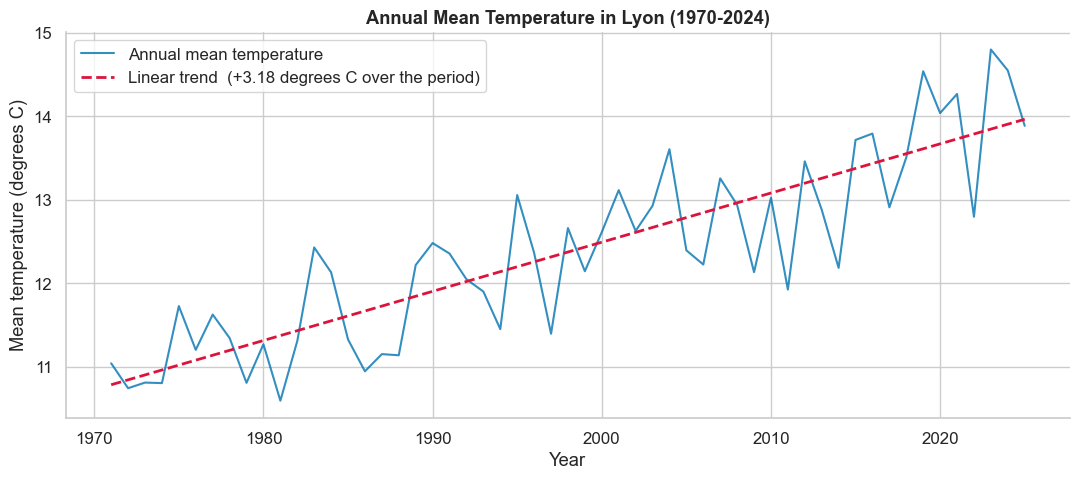

Estimated warming 1970->2024: 3.18 degrees C


In [132]:
# Annual mean temperature
df_annual = df_climate.set_index('time').resample('YE').mean().reset_index()

# Linear trend
X = np.arange(len(df_annual))
slope, intercept = np.polyfit(X, df_annual['temperature'].values, 1)
trend = intercept + slope * X
warming = trend[-1] - trend[0]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(df_annual['time'], df_annual['temperature'],
        color=PALETTE[0], linewidth=1.5, alpha=0.8, label='Annual mean temperature')
ax.plot(df_annual['time'], trend,
        color='crimson', linewidth=2, linestyle='--',
        label=f'Linear trend  (+{warming:.2f} degrees C over the period)')

ax.set_xlabel('Year')
ax.set_ylabel('Mean temperature (degrees C)')
ax.set_title('Annual Mean Temperature in Lyon (1970-2024)', fontweight='bold')
ax.legend(frameon=True)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
sns.despine()
plt.tight_layout()
plt.show()

print(f"Estimated warming 1970->2024: {warming:.2f} degrees C")


---
> **❓ Question 2 · Warming magnitude**
>
> - What is the estimated warming over 1970–2024?
> - Does this figure surprise you?
> - How does it compare to the global average (+1.1 °C since pre-industrial)?


### 1.2 Heatwaves

**Definition used here:** >= 3 consecutive days with `temperature_max` > 30 °C.

The helper function below returns a table of individual heatwave events.


In [133]:
def get_heatwave_events(df, temp_col='temperature', time_col='time',
                        q_pic=0.99, q_start=0.95, q_interrupt=0.90):
    """
    Quantile-based heatwave detection:
    - Trigger: temp > Spic (q99)
    - Event start/back-extension: contiguous days with temp > Sstart (q95)
    - Event ends when temp drops below Sinterup (q90)
    - Intensity = sum((temp - Sstart) / (Spic - Sstart)) over event days
                  (only positive contributions are counted)
    """
    d = df[[time_col, temp_col]].copy()
    d[time_col] = pd.to_datetime(d[time_col])
    d = d.sort_values(time_col).reset_index(drop=True)

    Spic = d[temp_col].quantile(q_pic)
    Sstart = d[temp_col].quantile(q_start)
    Sinterup = d[temp_col].quantile(q_interrupt)

    temps = d[temp_col].to_numpy(float)
    dates = d[time_col].to_numpy()
    n = len(d)
    denom = Spic - Sstart if Spic != Sstart else np.nan

    events = []
    i = 0
    while i < n:
        if temps[i] > Spic:
            # Extend backward using Sstart
            s = i
            while s > 0 and temps[s - 1] > Sstart:
                s -= 1

            # Extend forward until interruption threshold is crossed
            e = i
            while e + 1 < n and temps[e + 1] >= Sinterup:
                e += 1

            seg = temps[s:e + 1]
            if np.isnan(denom) or denom == 0:
                intensity = np.nan
            else:
                intensity = np.sum(np.maximum(seg - Sstart, 0) / denom)

            events.append({
                'start_date': pd.Timestamp(dates[s]),
                'end_date': pd.Timestamp(dates[e]),
                'duration_days': e - s + 1,
                'max_temp': float(np.max(seg)),
                'intensity': float(intensity)
            })

            i = e + 1  # skip to end of current event
        else:
            i += 1

    hw = pd.DataFrame(events)
    if not hw.empty:
        hw['year'] = hw['start_date'].dt.year

    return hw, {'Spic': Spic, 'Sstart': Sstart, 'Sinterup': Sinterup}


heatwaves, thresholds = get_heatwave_events(df_climate, temp_col='temperature')

print(
    f"Thresholds -> Spic (q99): {thresholds['Spic']:.2f}°C | "
    f"Sstart (q95): {thresholds['Sstart']:.2f}°C | "
    f"Sinterup (q90): {thresholds['Sinterup']:.2f}°C"
)
print(f"Total heatwave events detected: {len(heatwaves)}")
heatwaves.sort_values('duration_days', ascending=False).head(10)


Thresholds -> Spic (q99): 27.60°C | Sstart (q95): 24.40°C | Sinterup (q90): 22.40°C
Total heatwave events detected: 58


,start_date,end_date,duration_days,max_temp,intensity,year
54,2022-07-12,2022-08-13,33,31.7,27.25000,2022
19,2003-06-07,2003-06-30,24,29.3,15.43750,2003
57,2024-07-26,2024-08-17,23,30.2,14.18750,2024
47,2019-06-24,2019-07-14,21,30.7,15.46875,2019
28,2010-06-27,2010-07-16,20,28.5,8.96875,2010
26,2006-07-10,2006-07-27,18,29.5,17.00000,2006
21,2003-08-02,2003-08-19,18,31.5,23.62500,2003
2,1983-07-16,1983-08-01,17,31.7,20.37500,1983
46,2018-07-23,2018-08-08,17,31.6,20.15625,2018
51,2020-08-06,2020-08-22,17,29.3,9.43750,2020


---
> **❓ Question 3 · Heatwave frequency over time**
>
> Plot the **number of heatwave events per year** as a bar chart with a linear trend line.
>
> - In which decade do the first events appear?
> - Is there a clear trend?


In [134]:
# -- YOUR CODE HERE --
# Hint: use heatwaves.groupby('year').size()
# Then reindex to fill years with 0 heatwaves
# Plot with plt.bar and overlay a trend line


---
> **❓ Question 4 · Longest heatwave**
>
> Which event had the longest duration? In which year did it occur?


In [135]:
heatwaves.sort_values('duration_days', ascending=False).head(5)


,start_date,end_date,duration_days,max_temp,intensity,year
54,2022-07-12,2022-08-13,33,31.7,27.25000,2022
19,2003-06-07,2003-06-30,24,29.3,15.43750,2003
57,2024-07-26,2024-08-17,23,30.2,14.18750,2024
47,2019-06-24,2019-07-14,21,30.7,15.46875,2019
28,2010-06-27,2010-07-16,20,28.5,8.96875,2010


### 1.3 Heatwave days and intensity per year

Beyond frequency, two other metrics matter:
* **Heatwave days per year** – total days spent in heatwave conditions ($T > S_\text{start}$).
* **Annual intensity** – sum of per-event intensity indices as defined in 1.2, i.e. the cumulative normalised temperature excess $\sum \max(T - S_\text{start}, 0)\,/\,(S_\text{pic} - S_\text{start})$ aggregated over all events in the year. A higher value indicates years with more severe or prolonged heat stress.

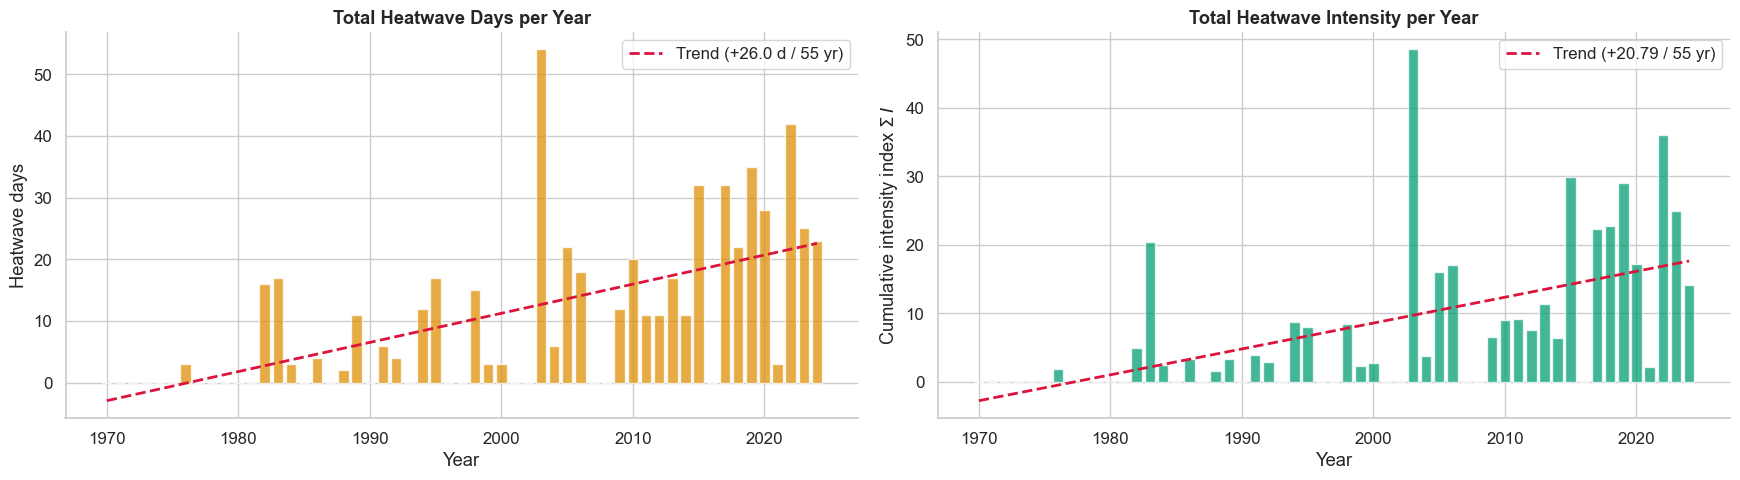

In [136]:
# ── Days per year ─────────────────────────────────────────────────────────────
all_years = pd.Series(0, index=df_annual['time'].dt.year.values, dtype=float)
days_per_year = heatwaves.groupby('year')['duration_days'].sum()
days_per_year = all_years.add(days_per_year, fill_value=0)

# ── Intensity per year: sum of per-event intensity indices (from 1.2) ─────────
intensity_per_year = heatwaves.groupby('year')['intensity'].sum()
intensity_per_year = intensity_per_year.reindex(all_years.index, fill_value=0)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(FIG_W * 1.6, FIG_H))

# Left: days
ax = axes[0]
Xd = np.arange(len(days_per_year))
sl, ic = np.polyfit(Xd, days_per_year.values, 1)
ax.bar(days_per_year.index, days_per_year.values,
       color=PALETTE[1], alpha=0.75)
ax.plot(days_per_year.index, ic + sl * Xd,
        color='crimson', linewidth=2, linestyle='--',
        label=f'Trend (+{sl*55:.1f} d / 55 yr)')
ax.set_xlabel('Year')
ax.set_ylabel('Heatwave days')
ax.set_title('Total Heatwave Days per Year', fontweight='bold')
ax.legend(frameon=True)

# Right: intensity
ax = axes[1]
Xi = np.arange(len(intensity_per_year))
sl2, ic2 = np.polyfit(Xi, intensity_per_year.values, 1)
ax.bar(intensity_per_year.index, intensity_per_year.values,
       color=PALETTE[2], alpha=0.75)
ax.plot(intensity_per_year.index, ic2 + sl2 * Xi,
        color='crimson', linewidth=2, linestyle='--',
        label=f'Trend (+{sl2*55:.2f} / 55 yr)')
ax.set_xlabel('Year')
ax.set_ylabel(r'Cumulative intensity index $\Sigma\,I$')
ax.set_title('Total Heatwave Intensity per Year', fontweight='bold')
ax.legend(frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

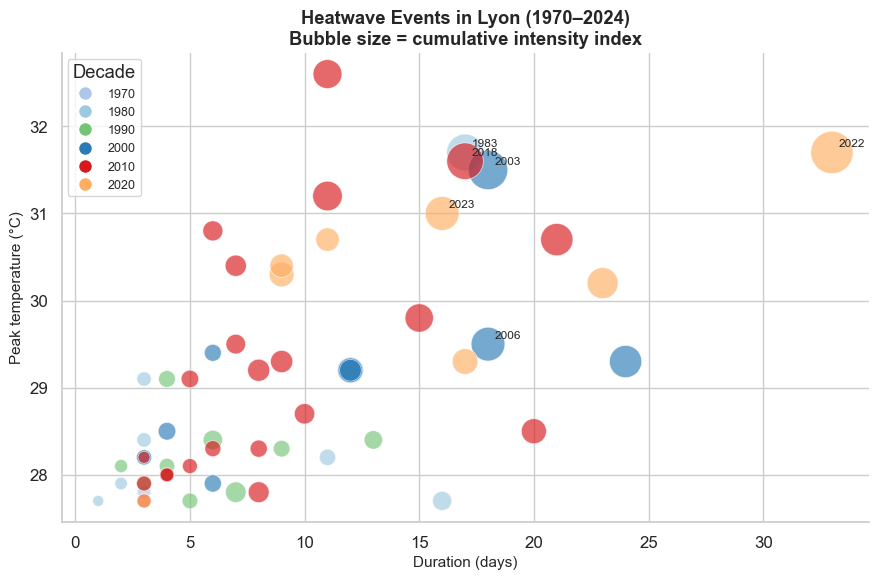

In [137]:
# ── Bubble chart: duration (x), max_temp (y), bubble size = intensity ─────────
from matplotlib.lines import Line2D

# Scale bubble area proportional to intensity
sz = (heatwaves['intensity'] / heatwaves['intensity'].max()) * 900 + 30

# Colour by decade
decade = (heatwaves['year'] // 10) * 10
decade_colors = {1970: '#aec7e8', 1980: '#9ecae1', 1990: '#74c476',
                 2000: '#2c7bb6', 2010: '#d7191c', 2020: '#fdae61'}
colors = decade.map(decade_colors)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(heatwaves['duration_days'], heatwaves['max_temp'],
           s=sz, c=colors, alpha=0.65, edgecolors='white', linewidths=0.6)

# Label the 6 most intense events
for _, row in heatwaves.nlargest(6, 'intensity').iterrows():
    ax.annotate(str(int(row['year'])),
                xy=(row['duration_days'], row['max_temp']),
                xytext=(5, 4), textcoords='offset points', fontsize=8.5)

ax.set_xlabel('Duration (days)', fontsize=11)
ax.set_ylabel('Peak temperature (°C)', fontsize=11)
ax.set_title('Heatwave Events in Lyon (1970–2024)\nBubble size = cumulative intensity index',
             fontweight='bold')

# Decade legend
handles = [Line2D([0], [0], marker='o', color='w',
                  markerfacecolor=c, markersize=10, label=str(d))
           for d, c in decade_colors.items() if d in decade.values]
ax.legend(handles=handles, title='Decade', frameon=True, loc='upper left', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

---
> **❓ Question 5 · Analysis of the dependence between duration, peak and intensity**
>
> What are your thoughts on the links between duration, peak and intensity ? Where does that come from?

---
## Part 2 – Spatial Exposure: Local Climate Zones

**Local Climate Zones (LCZ)** classify urban and rural landscapes into 17 types based on
surface cover, building morphology, and human activity.  In the context of urban heat:

| LCZ class | Description | 
|-----------|-------------|
| 1 | Compact high |
| 2 | Compact mid-rise |
| 3 | Compact low-rise |
| 4 | Open high-rise |
| 5 | Open mid-rise |
| 6 | Open low-rise |
| 7 | Lightweight low-rise, densely built |
| 8 | Large buildings |
| 9 |  Scattered settlement of houses |
| A - 11 | Densely wooded areas |
| B - 12 | Sparse wooded area |
| C - 13 | Heterogeneous green space |
| D - 14 | Low vegetation |
| E - 15 | Bare rock or paved |
| F - 16 | Bare soil or sand |
| G - 17 | Water | 

We load a pre-processed GeoPackage that combines LCZ polygons with:
- `ind` – total population (200 m grid)
- `ind_80p` – population aged 80+
- `ind_snv` – median standard of living (euros/year)
- `ver` – vegetation cover (%)
- `ror` – impervious surface cover (%)
- `dist_hospital` – distance to nearest hospital/clinic (m)


In [138]:
import geopandas as gpd
import xarray as xr
path = 'data/ds_filo_lcz_aligned.nc'
ds = xr.open_dataset(path)
import os
import numpy as np
import matplotlib.pyplot as plt


# Assign source CRS, then reproject
ds = ds.rio.write_crs("EPSG:2154", inplace=False)
ds = ds.rio.reproject("EPSG:4326")
lenx = ds.dims["x"]
leny = ds.dims["y"]
ds_clip = ds.isel(x=slice(lenx//4, 3*lenx//4), y=slice(leny//4, 3*leny//4))


> **❓ Question 6 · What variables are included in the xarray?**

<!-- ...existing code... -->
### 2.1 Maps (Lyon + périphérie proche)

On utilise un **helper** (`plot_two_maps_side_by_side`) pour tracer rapidement deux cartes comparables
(même fond, mêmes extents, colorbars indépendantes).



In [139]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray  # noqa
import geopandas as gpd
# import contextily as ctx
from shapely.geometry import box
from cartopy.io import shapereader


def _prepare_da_for_map(da, target_crs="EPSG:3857"):
    """
    Ensure a DataArray has a CRS and reproject it to target_crs.
    """
    if not isinstance(da, xr.DataArray):
        raise TypeError("Each input must be an xarray.DataArray.")

    da = da.squeeze()
    if da.ndim != 2:
        raise ValueError(f"DataArray must be 2D after squeeze(), got shape {da.shape}")

    # spatial dims guess
    dims = list(da.dims)
    x_candidates = ["x", "lon", "longitude"]
    y_candidates = ["y", "lat", "latitude"]

    x_dim = next((d for d in dims if d in x_candidates), None)
    y_dim = next((d for d in dims if d in y_candidates), None)

    if x_dim is None or y_dim is None:
        raise ValueError(f"Could not infer spatial dims from {dims}")

    if x_dim != "x" or y_dim != "y":
        da = da.rename({x_dim: "x", y_dim: "y"})

    da = da.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=False)

    if da.rio.crs is None:
        raise ValueError(
            "DataArray has no CRS. Add one first, e.g.:\n"
            "da = da.rio.write_crs('EPSG:2154')"
        )

    if str(da.rio.crs) != target_crs:
        da = da.rio.reproject(target_crs)

    return da

def _load_rivers_and_lakes(target_crs="EPSG:3857"):
    """
    Load Natural Earth rivers and lakes as GeoDataFrames.
    """
    rivers_path = shapereader.natural_earth(
        resolution="10m",
        category="physical",
        name="rivers_lake_centerlines",
    )
    lakes_path = shapereader.natural_earth(
        resolution="10m",
        category="physical",
        name="lakes",
    )

    rivers = gpd.read_file(rivers_path).to_crs(target_crs)
    lakes = gpd.read_file(lakes_path).to_crs(target_crs)
    return rivers, lakes

def _plot_one_panel(
    ax,
    da,
    title="",
    cmap="viridis",
    vmin=None,
    vmax=None,
    alpha=0.75,
    add_colorbar=True,
    rivers=None,
    lakes=None,
):
    """
    Plot one DataArray on one matplotlib axis with basemap + rivers.
    """
    x = da["x"].values
    y = da["y"].values
    arr = da.values.astype(float)

    extent = [float(np.nanmin(x)), float(np.nanmax(x)),
              float(np.nanmin(y)), float(np.nanmax(y))]

    im = ax.imshow(
        arr,
        extent=extent,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        alpha=alpha,
        interpolation="nearest",
        zorder=3,
    )

    # Basemap with roads + city names in background

    # Lakes and rivers
    if lakes is not None and not lakes.empty:
        lakes.clip(box(*extent)).plot(
            ax=ax,
            color="#9ecae1",
            edgecolor="#6baed6",
            linewidth=0.4,
            alpha=0.9,
            zorder=2,
        )

    if rivers is not None and not rivers.empty:
        rivers.clip(box(*extent)).plot(
            ax=ax,
            color="#3182bd",
            linewidth=0.7,
            alpha=0.9,
            zorder=4,
        )

    ax.set_title(title)
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_axis_off()

    if add_colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    return im

def plot_two_maps_side_by_side(
    da_left,
    da_right,
    *,
    title_left="Left map",
    title_right="Right map",
    cmap_left="viridis",
    cmap_right="viridis",
    vmin_left=None,
    vmax_left=None,
    vmin_right=None,
    vmax_right=None,
    alpha_left=0.75,
    alpha_right=0.75,
    same_extent=True,
    same_crs="EPSG:3857",
    figsize=(14, 7),
):
    """
    Plot two DataArrays side by side with:
    - background basemap (roads + big city names)
    - rivers and lakes overlay
    - independent colorbars

    Parameters
    ----------
    da_left, da_right : xarray.DataArray
        2D rasters with CRS readable by rioxarray.
    same_extent : bool
        If True, force both panels to the union of both extents.
    same_crs : str
        CRS used for plotting, default EPSG:3857 (good for web basemaps).
    """
    left = _prepare_da_for_map(da_left, target_crs=same_crs)
    right = _prepare_da_for_map(da_right, target_crs=same_crs)

    rivers, lakes = _load_rivers_and_lakes(target_crs=same_crs)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    _plot_one_panel(
        axes[0],
        left,
        title=title_left,
        cmap=cmap_left,
        vmin=vmin_left,
        vmax=vmax_left,
        alpha=alpha_left,
        add_colorbar=True,
        rivers=rivers,
        lakes=lakes,
    )

    _plot_one_panel(
        axes[1],
        right,
        title=title_right,
        cmap=cmap_right,
        vmin=vmin_right,
        vmax=vmax_right,
        alpha=alpha_right,
        add_colorbar=True,
        rivers=rivers,
        lakes=lakes,
    )

    if same_extent:
        def get_extent(da):
            x = da["x"].values
            y = da["y"].values
            return [float(np.nanmin(x)), float(np.nanmax(x)),
                    float(np.nanmin(y)), float(np.nanmax(y))]

        e1 = get_extent(left)
        e2 = get_extent(right)

        union_extent = [
            min(e1[0], e2[0]),
            max(e1[1], e2[1]),
            min(e1[2], e2[2]),
            max(e1[3], e2[3]),
        ]

        for ax in axes:
            ax.set_xlim(union_extent[0], union_extent[1])
            ax.set_ylim(union_extent[2], union_extent[3])

    plt.tight_layout()
    return fig, axes

> **❓ Question 6 · Spatial differences between LCZ** 
- Where are concentrated the compact classes (1–3)?
- Where are the open classes (4–6), large low-rise (8), sparsely built (9) mostly located?
- Where are the natural classes (11–15) and water (17) mostly located?

(<Figure size 1400x700 with 4 Axes>,
 array([<Axes: title={'center': 'Dense LCZ (1-3)'}>,
        <Axes: title={'center': 'Natural LCZ (11-15)'}>], dtype=object))

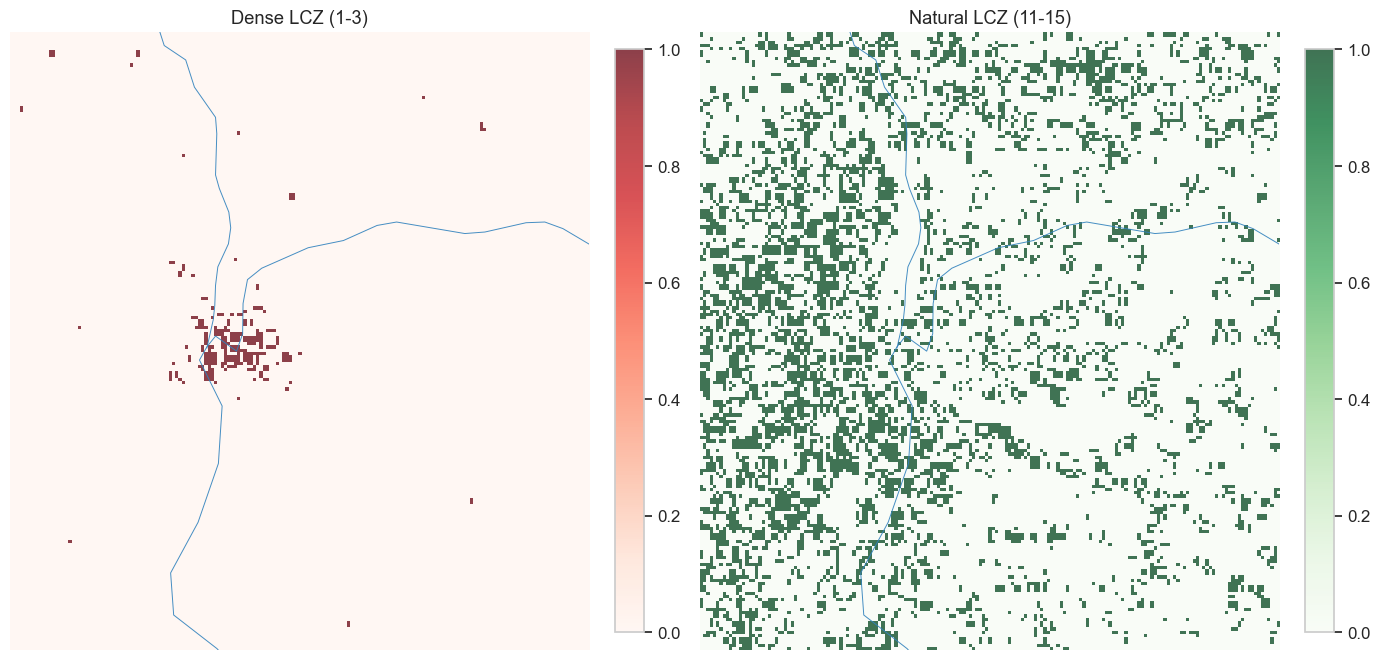

In [140]:
da_dense = (ds_clip["lcz_int"].isin([1,2,3])).astype(float)
da_natural = (ds_clip["lcz_int"].isin([11,12,13,14,15])).astype(float)

plot_two_maps_side_by_side(
        da_dense,
        da_natural,
        title_left="Dense LCZ (1-3)",
        title_right="Natural LCZ (11-15)",
        cmap_left="Reds",
        cmap_right="Greens",
)

(<Figure size 1400x700 with 4 Axes>,
 array([<Axes: title={'center': 'Dense LCZ (1-3)'}>,
        <Axes: title={'center': 'Mixed LCZ (4-10)'}>], dtype=object))

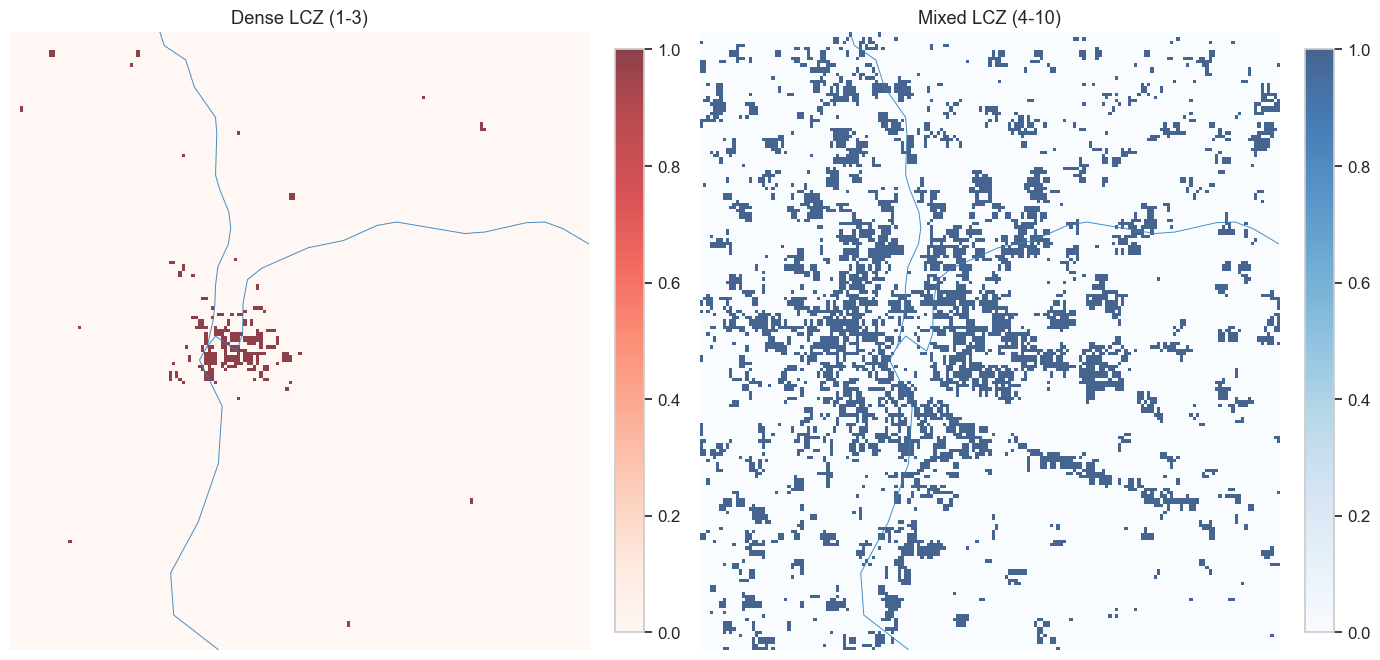

In [141]:
da_dense = (ds_clip["lcz_int"].isin([1,2,3])).astype(float)
da_mixed = (ds_clip["lcz_int"].isin([4,5,6,7,8,9,10])).astype(float)

plot_two_maps_side_by_side(
        da_dense,
        da_mixed,
        title_left="Dense LCZ (1-3)",
        title_right="Mixed LCZ (4-10)",
        cmap_left="Reds",
        cmap_right="Blues",
)

> **❓ Question 7 · Spatial differences in the indicators used to create LCZ maps**
 
You can find here the documentation of the indicators used to create the LCZ maps: https://www.data.gouv.fr/api/1/datasets/r/f80e08a4-ecd1-42a2-a8d6-963af16aec75

- Which indicators are used to create the LCZ maps?
- How do they relate to the LCZ classes?
- Compare them spatially.

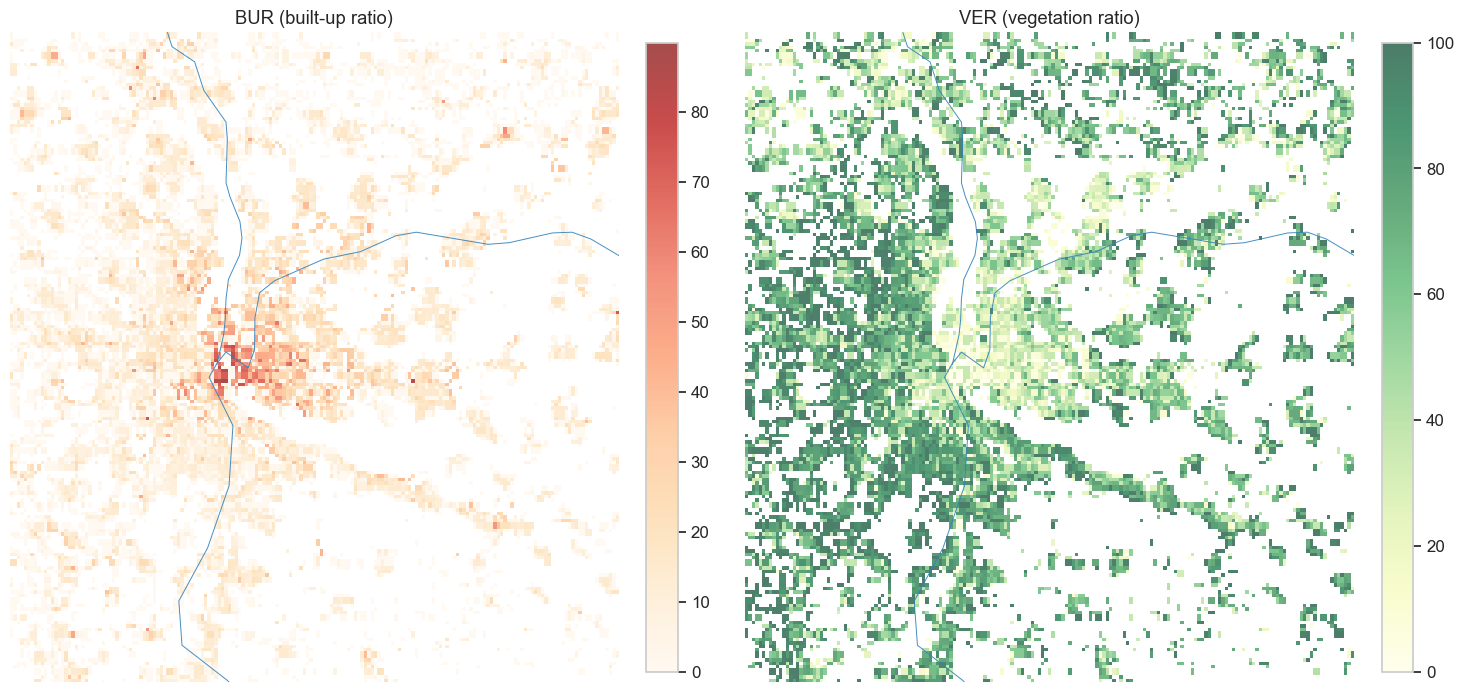

In [142]:
da_left = ds_clip["bur"]
da_right = ds_clip["ver"]

fig, axes = plot_two_maps_side_by_side(
    da_left, da_right,
    title_left="BUR (built-up ratio)",
    title_right="VER (vegetation ratio)",
    cmap_left="OrRd", cmap_right="YlGn",
    alpha_left=0.70, alpha_right=0.70,
    figsize=(15, 7)
)


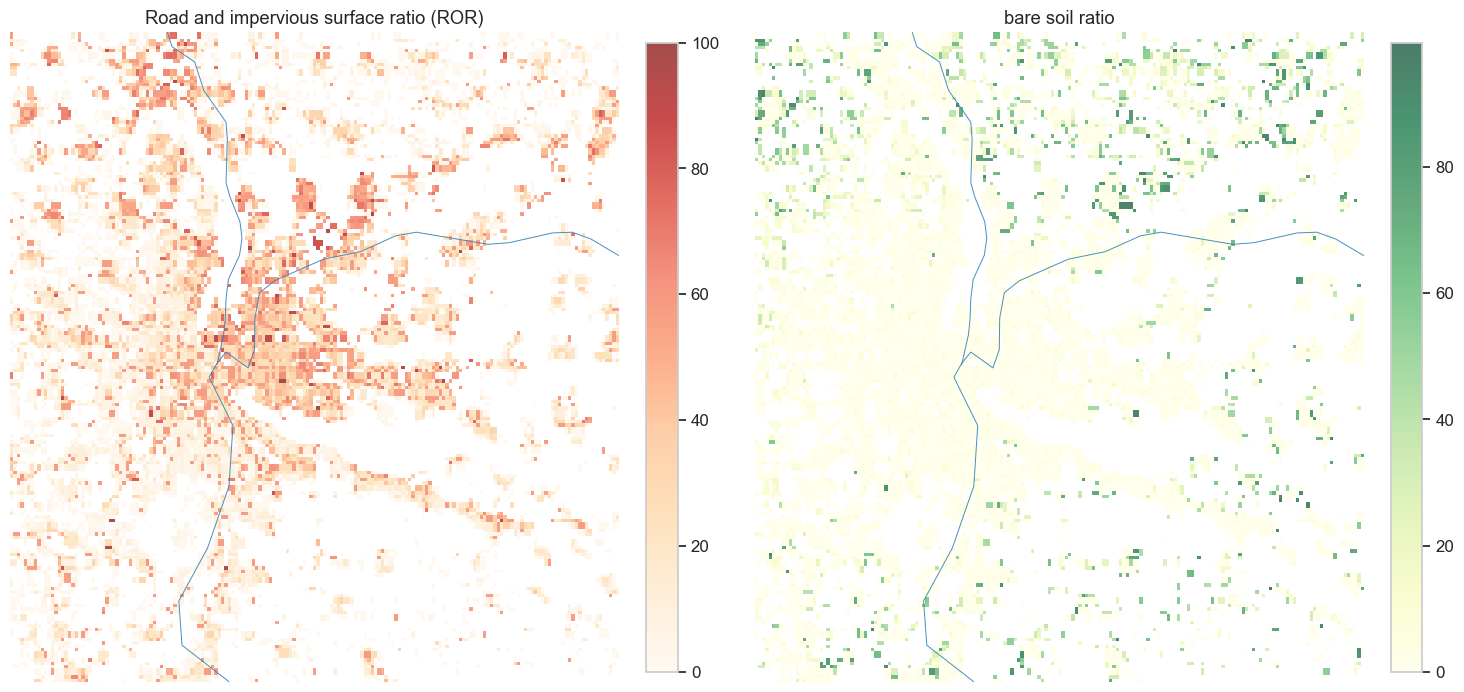

In [143]:
da_left = ds_clip["ror"] 
da_right = ds_clip["bsr"]

fig, axes = plot_two_maps_side_by_side(
    da_left, da_right,
    title_left="Road and impervious surface ratio (ROR)",
    title_right="bare soil ratio",
    cmap_left="OrRd", cmap_right="YlGn",
    alpha_left=0.70, alpha_right=0.70,
    figsize=(15, 7)
)

> **❓ Question 8.1 · Population density and standard of living**
>
> Run the two cells below to display:
> - Population density (`ind`) vs median standard of living (`ind_snv`)
> - Share of elderly population (80+) vs share of young children (0–5)
>
> Then answer:
> 1. Where is population most concentrated in the Lyon area?
> 2. Do the highest-income areas overlap with the most densely populated zones?
> 3. Which age groups appear to be spatially segregated?

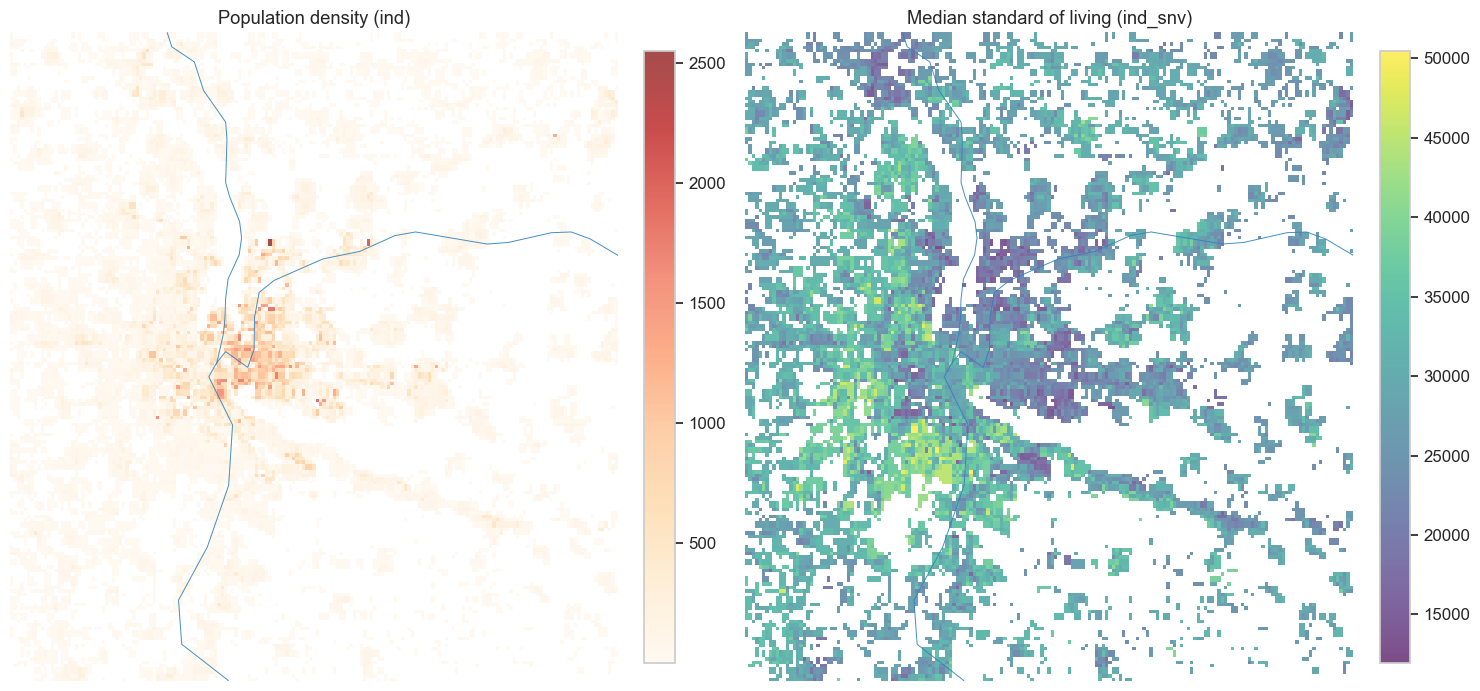

In [144]:
da_left = ds_clip["ind"]
da_right = ds_clip["ind_snv"]

fig, axes = plot_two_maps_side_by_side(
    da_left, da_right,
    title_left="Population density (ind)",
    title_right="Median standard of living (ind_snv)",
    cmap_left="OrRd", cmap_right="viridis",
    alpha_left=0.70, alpha_right=0.70,
    figsize=(15, 7)
)

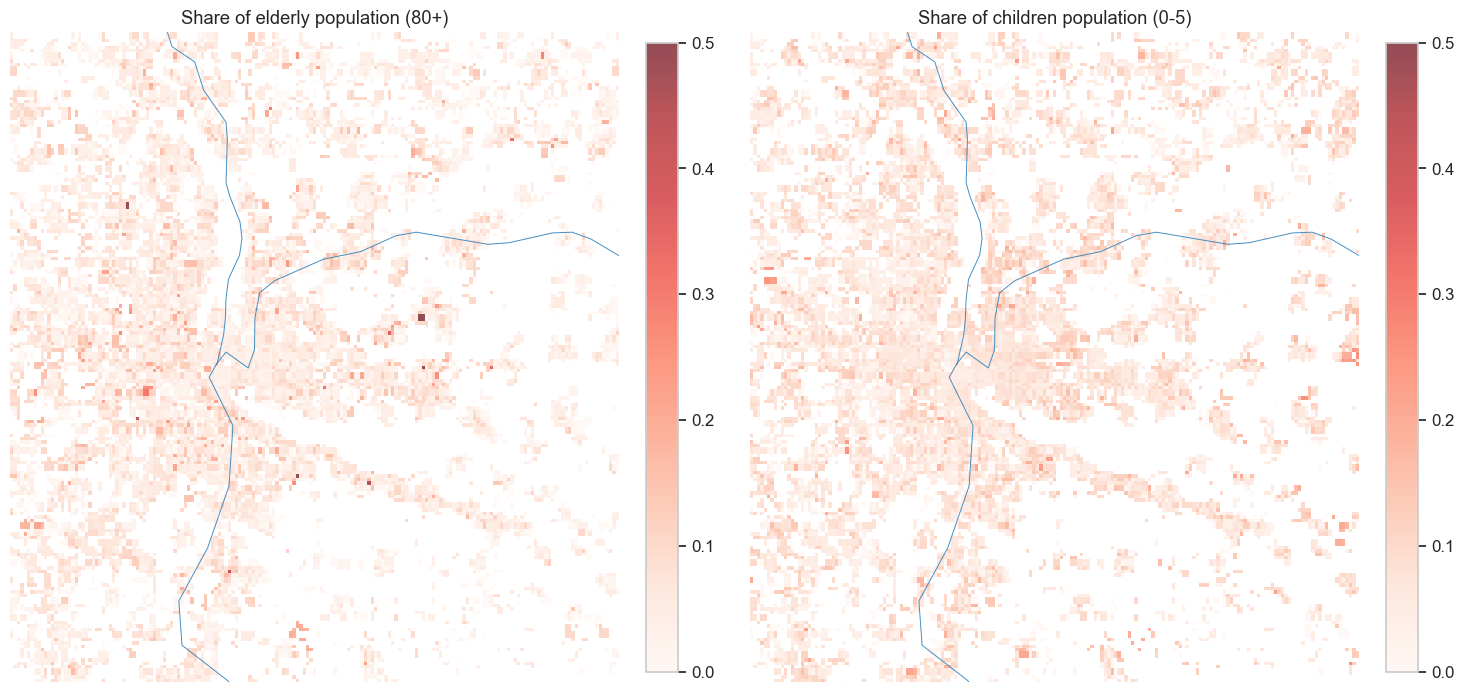

In [145]:
da_left = ds_clip["ind_80p"]/ds_clip["ind"]
da_right = ds_clip["ind_0_5"]/ds_clip["ind"]

fig, axes = plot_two_maps_side_by_side(
    da_left, da_right,
    title_left="Share of elderly population (80+)",
    title_right="Share of children population (0-5)",
    cmap_left="Reds", cmap_right="Reds",
    alpha_left=0.70, alpha_right=0.70,
    figsize=(15, 7), vmax_left=0.5, vmax_right=0.5, vmin_left=0, vmin_right=0
)

> **❓ Question 8.2 · Vegetation cover and income — a spatial story**
>
> The two maps below compare:
> - Dense urban LCZ classes (1–3: compact fabric) with median standard of living
> - Vegetation cover (`ver`) with median standard of living
>
> 1. Where are the most urbanised (compact) LCZ classes concentrated?
> 2. Is there a visible spatial correlation between vegetation cover and income?  
>    *(Hint: do green areas and high-income areas tend to coincide?)*
> 3. Which areas combine **high impervious surface** AND **low income**?  
>    Why might this double burden be a climate justice concern?

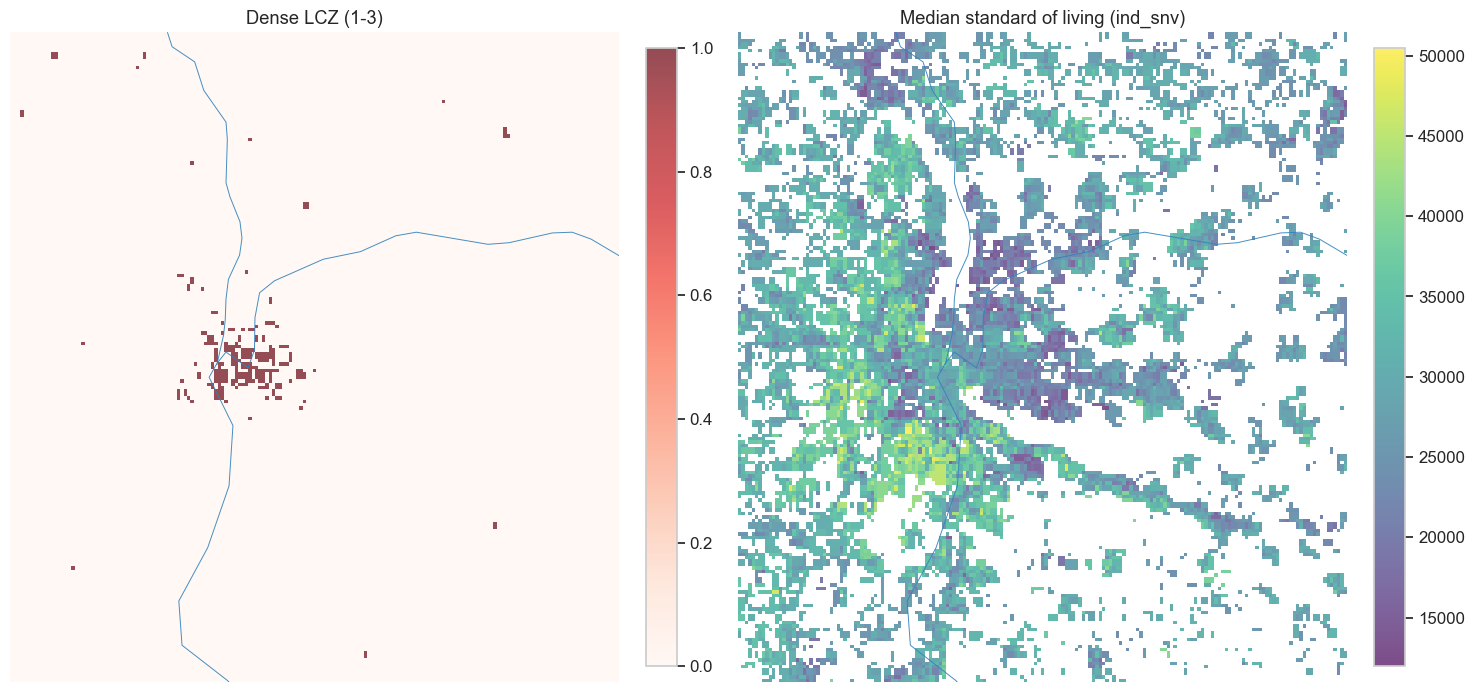

In [146]:
da_left = ds_clip.lcz_int.isin([1,2,3]).astype(float)
da_right = ds_clip.ind_snv

fig, axes = plot_two_maps_side_by_side(
    da_left, da_right,
    title_left="Dense LCZ (1-3)",
    title_right="Median standard of living (ind_snv)",
    cmap_left="Reds", cmap_right="viridis",
    alpha_left=0.70, alpha_right=0.70,
    figsize=(15, 7)
)


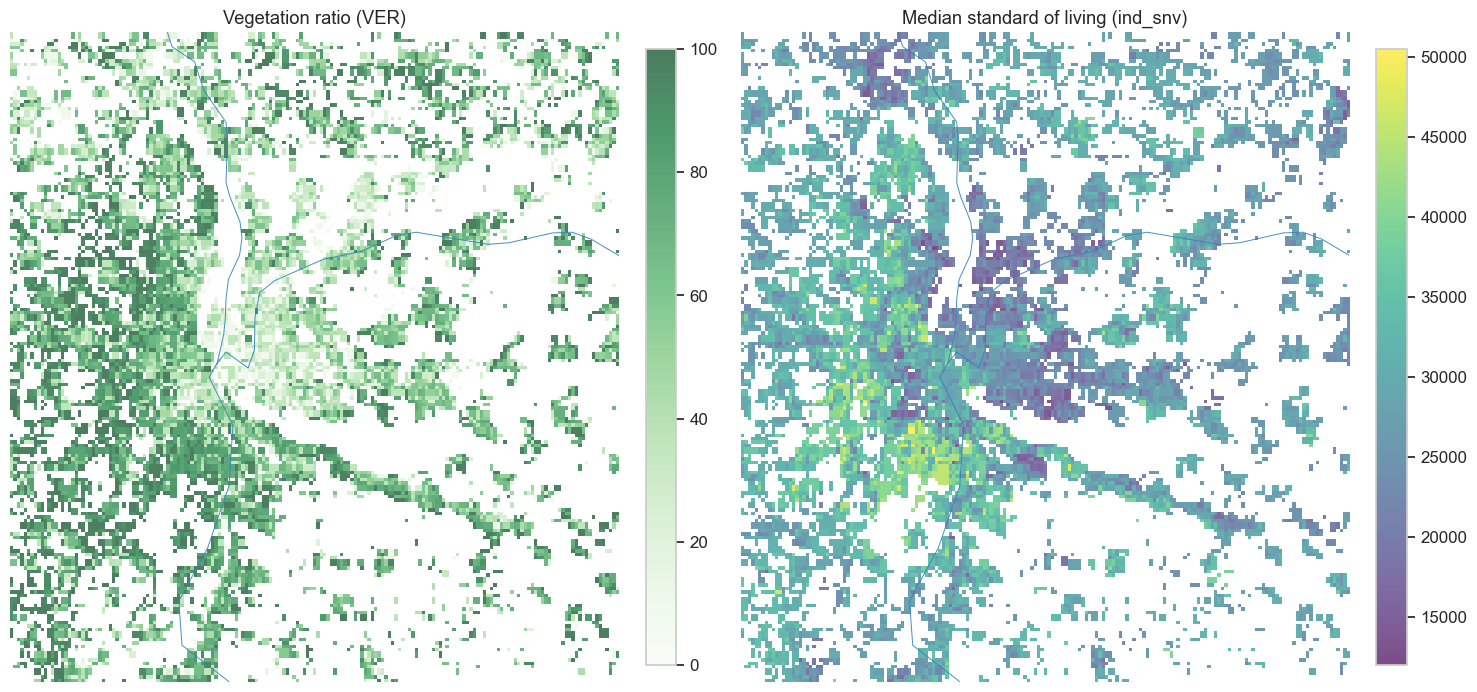

In [147]:
da_left = ds_clip.ver
da_right = ds_clip.ind_snv

fig, axes = plot_two_maps_side_by_side(
    da_left, da_right,
    title_left="Vegetation ratio (VER)",
    title_right="Median standard of living (ind_snv)",
    cmap_left="Greens", cmap_right="viridis",
    alpha_left=0.70, alpha_right=0.70,
    figsize=(15, 7)
)


> **❓ Question 8.3 · Quantitative comparison across LCZ groups**
>
> The table below summarises mean vegetation cover, median income, and population structure
> for three LCZ groups (compact urban 1–3, open/mixed urban 4–10, natural 11–15).
>
> 1. What is the mean vegetation cover in compact urban areas (LCZ 1–3)?  
>    How does it compare to open/mixed urban and natural areas?
> 2. Which LCZ group has the highest median standard of living?
> 3. Which LCZ group has the largest share of elderly population (80+)?  
>    What are the climate justice implications, given that the elderly are among the most  
>    vulnerable during heatwaves?

In [148]:
# Compare indicators across 3 LCZ groups: 1–3, 4–10, 11–15
lcz_groups = {
    "LCZ 1–3 (compact urban)": [1, 2, 3],
    "LCZ 4–10 (open/mixed urban)": [4, 5, 6, 7, 8, 9, 10],
    "LCZ 11–15 (natural)": [11, 12, 13, 14, 15],
}

rows = []
for group_name, classes in lcz_groups.items():
    mask = ds_clip["lcz_int"].isin(classes)

    total_pop = ds_clip["ind"].where(mask).sum(dim=["x", "y"], skipna=True).item()
    old_pop = ds_clip["ind_80p"].where(mask).sum(dim=["x", "y"], skipna=True).item()
    young_pop = ds_clip["ind_0_5"].where(mask).sum(dim=["x", "y"], skipna=True).item()

    rows.append({
        "LCZ group": group_name,
        "Mean vegetation cover (%)": ds_clip["ver"].where(mask).mean(dim=["x", "y"], skipna=True).item(),
        "Mean median standard of living (€/year)": ds_clip["ind_snv"].where(mask).mean(dim=["x", "y"], skipna=True).item(),
        "Total population": int(round(total_pop)),
        "Population aged 80+": int(round(old_pop)),
        "Population aged 0–5": int(round(young_pop)),
        "Number of cells": int(mask.sum().item())
    })

table_lcz_compare = pd.DataFrame(rows)

display(
    table_lcz_compare.style
    .format({
        "Mean vegetation cover (%)": "{:,.2f}",
        "Mean median standard of living (€/year)": "{:,.2f}",
        "Total population": "{:,}",
        "Population aged 80+": "{:,}",
        "Population aged 0–5": "{:,}",
        "Number of cells": "{:,}"
    })
    .hide(axis="index")
    .set_caption("Comparison of vegetation, income, and population structure across LCZ groups")
)

LCZ group,Mean vegetation cover (%),Mean median standard of living (€/year),Total population,Population aged 80+,Population aged 0–5,Number of cells
LCZ 1–3 (compact urban),10.21,"26,400.29","173,939","7,534","12,366",235
LCZ 4–10 (open/mixed urban),52.75,"28,366.60","799,204","39,570","64,291","5,435"
LCZ 11–15 (natural),76.72,"30,046.93","355,062","18,447","27,325","6,978"


---
## Part 3 – Climate Justice Analysis

We now test whether socioeconomic status predicts exposure to heat risk factors.
We divide the study area into **income deciles** (D1 = poorest 10%, D10 = richest 10%)
and compare four indicators across deciles.


In [149]:
# Convert the xarray dataset to a tabular dataframe
lcz = ds_clip.to_dataframe().reset_index()

# Work only on cells with population/income data and urban LCZ (class < 10)
dt = lcz.dropna(subset=['lcz_int', 'ind_snv', 'ver', 'ror', 'dist_hospital', 
                        'dist_clinic', 'dist_doctors']).copy()
dt = dt[dt['lcz_int'] < 10].copy()   # exclude natural / rural zones

# Income deciles
dt['decile_snv'] = pd.qcut(dt['ind_snv'].rank(method='first'), 10, labels=False)

print(f"Urban polygons with income data: {len(dt):,}")



Urban polygons with income data: 5,670


### 3.1 Vegetation cover by income decile

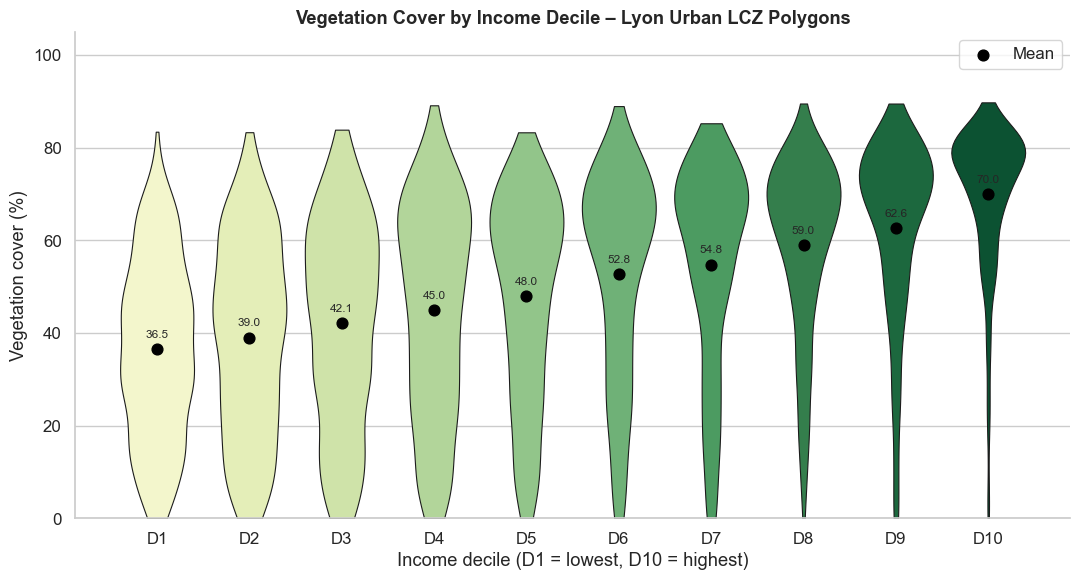

In [150]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 1))

pal_g = sns.color_palette("YlGn", 10)
sns.violinplot(x='decile_snv', y='ver', data=dt,
               order=range(10), palette=pal_g, ax=ax,
               inner=None, cut=0, linewidth=0.8)

means_ver = dt.groupby('decile_snv')['ver'].mean()
ax.scatter(means_ver.index, means_ver.values,
           color='black', s=60, zorder=5, label='Mean')

for i, val in enumerate(means_ver):
    ax.text(i, val + 2.5, f'{val:.1f}', ha='center', fontsize=8.5)

ax.set_xticks(range(10))
ax.set_xticklabels([f'D{i+1}' for i in range(10)])
ax.set_xlabel('Income decile (D1 = lowest, D10 = highest)')
ax.set_ylabel('Vegetation cover (%)')
ax.set_title('Vegetation Cover by Income Decile – Lyon Urban LCZ Polygons',
             fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.show()


---
> **❓ Question 6 · Green inequality**
>
> - Describe the relationship between income and vegetation cover.
> - Is the difference between D1 and D10 large?
> - What policy interventions could reduce this gap?


### 3.2 Impervious surface cover by income decile

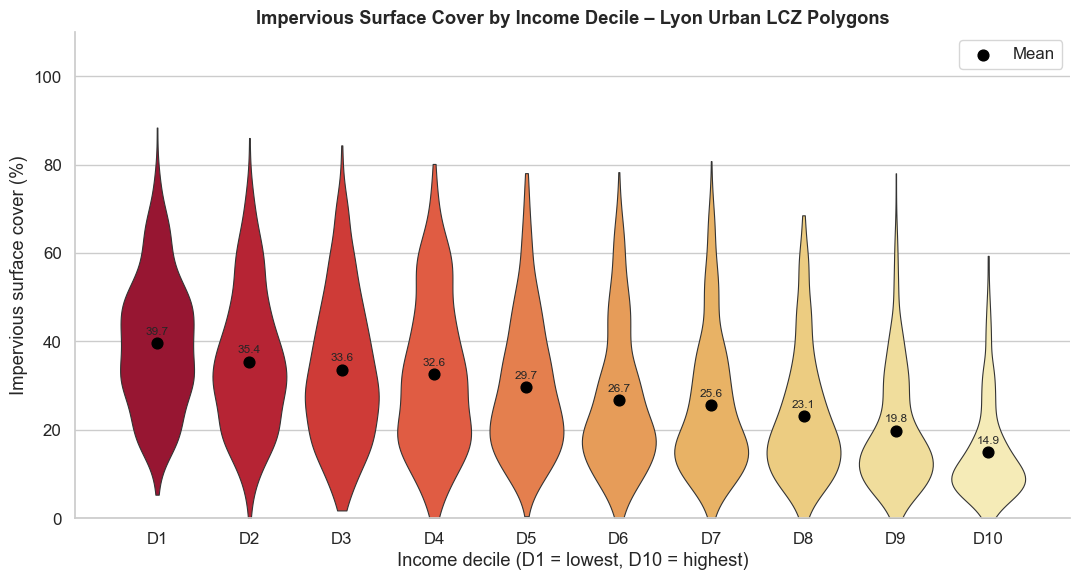

In [151]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 1))

pal_r = sns.color_palette("YlOrRd", 10)[::-1]
sns.violinplot(x='decile_snv', y='ror', data=dt,
               order=range(10), palette=pal_r, ax=ax,
               inner=None, cut=0, linewidth=0.8)

means_ror = dt.groupby('decile_snv')['ror'].mean()
ax.scatter(means_ror.index, means_ror.values,
           color='black', s=60, zorder=5, label='Mean')

for i, val in enumerate(means_ror):
    ax.text(i, val + 2, f'{val:.1f}', ha='center', fontsize=8.5)

ax.set_xticks(range(10))
ax.set_xticklabels([f'D{i+1}' for i in range(10)])
ax.set_xlabel('Income decile (D1 = lowest, D10 = highest)')
ax.set_ylabel('Impervious surface cover (%)')
ax.set_title('Impervious Surface Cover by Income Decile – Lyon Urban LCZ Polygons',
             fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.show()


### 3.3 Distance to nearest hospital/clinic by income decile

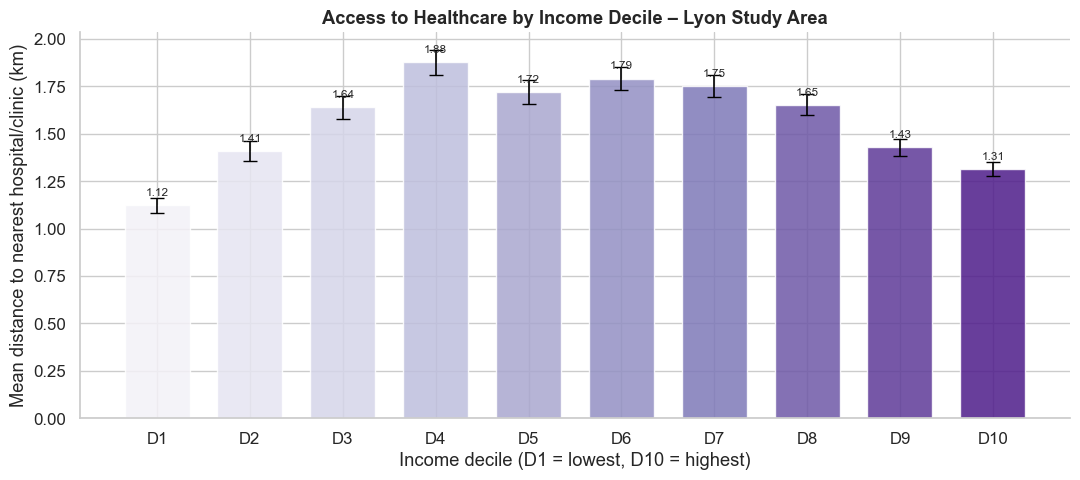

In [152]:
stats_h = dt.groupby('decile_snv')['dist_doctors'].agg(['mean','sem']).sort_index()
stats_h.columns = ['mean', 'sem']

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
pal_p = sns.color_palette("Purples", 10)
ax.bar(stats_h.index, stats_h['mean'] / 1000,
       color=pal_p, alpha=0.85, width=0.7)
ax.errorbar(stats_h.index, stats_h['mean'] / 1000,
            yerr=stats_h['sem'] / 1000,
            fmt='none', ecolor='black', capsize=5, linewidth=1.2)

for i, val in enumerate(stats_h['mean'] / 1000):
    ax.text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=8.5)

ax.set_xticks(range(10))
ax.set_xticklabels([f'D{i+1}' for i in range(10)])
ax.set_xlabel('Income decile (D1 = lowest, D10 = highest)')
ax.set_ylabel('Mean distance to nearest hospital/clinic (km)')
ax.set_title('Access to Healthcare by Income Decile – Lyon Study Area',
             fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()


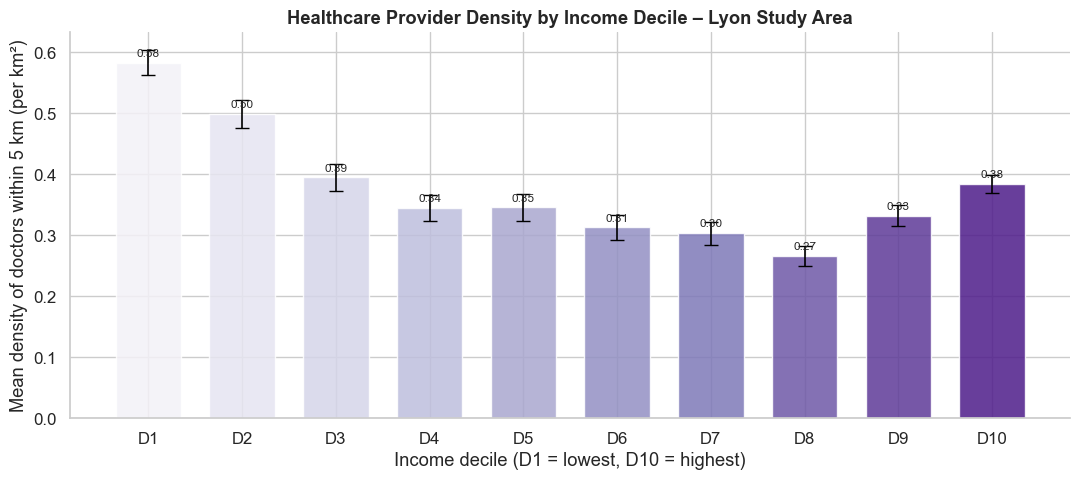

In [153]:
stats_h = dt.groupby('decile_snv')['dens5km_doctors'].agg(['mean','sem']).sort_index()
stats_h.columns = ['mean', 'sem']

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
pal_p = sns.color_palette("Purples", 10)
ax.bar(stats_h.index, stats_h['mean'],
       color=pal_p, alpha=0.85, width=0.7)
ax.errorbar(stats_h.index, stats_h['mean'],
            yerr=stats_h['sem'],
            fmt='none', ecolor='black', capsize=5, linewidth=1.2)

for i, val in enumerate(stats_h['mean']):
    ax.text(i, val + 0.01, f'{val:.2f}', ha='center', fontsize=8.5)

ax.set_xticks(range(10))
ax.set_xticklabels([f'D{i+1}' for i in range(10)])
ax.set_xlabel('Income decile (D1 = lowest, D10 = highest)')
ax.set_ylabel('Mean density of doctors within 5 km (per km²)')
ax.set_title('Healthcare Provider Density by Income Decile – Lyon Study Area',
             fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()


---
> **❓ Question 7 · Double burden**
>
> Combining the findings from sections 3.1, 3.2, and 3.3:
>
> 1. Which income group faces the worst *combination* of heat exposure and healthcare access?
> 2. Propose a composite **vulnerability index** that captures this double burden.
>    What variables would you include?
> 3. What additional data would strengthen this analysis?


---
### 3.4 Synthesis: linear regression with confidence intervals

We now formalise the relationships observed visually in the bivariate maps
by fitting OLS regressions at the **pixel level**.
Two outcome variables capture complementary dimensions of climate vulnerability:

| Dependent variable | Interpretation |
|--------------------|----------------|
| Vegetation cover `ver` (%) | Direct heat-mitigation capacity of each cell |
| Share of elderly 80+ (`ind_80p / ind`) | Age-related vulnerability to extreme heat |

For each, the explanatory variable is **median standard of living** (`ind_snv`, k€/year).
The shaded band shows the **95 % pointwise confidence interval** of the regression line.

Text(0.5, 1.0, 'Multivariate regression coefficients with 95% CI')

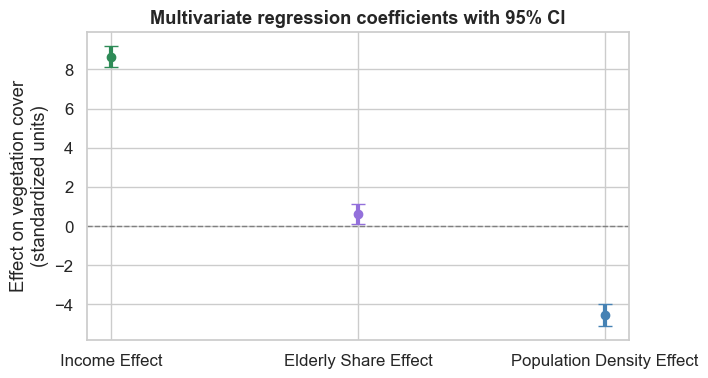

In [154]:
import statsmodels.api as sm

ver_flat = dt['ver'].to_numpy(float)
snv_flat = dt['ind_snv'].to_numpy(float)
ind_flat = dt['ind'].to_numpy(float)
elderly_rate = (dt['ind_80p'] / dt['ind']).to_numpy(float)

#normalize everything to have comparable scales (k€ for income, % for elderly share)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
snv_scaled = scaler.fit_transform(snv_flat.reshape(-1, 1)).flatten()
elderly_scaled = scaler.fit_transform(elderly_rate.reshape(-1, 1)).flatten()
ind_scaled = scaler.fit_transform(ind_flat.reshape(-1, 1)).flatten()    

# Prepare data
mask = np.isfinite(ver_flat) & np.isfinite(snv_flat) & np.isfinite(elderly_rate)

X = sm.add_constant(np.column_stack([
    snv_scaled[mask] ,       # income in k€
    elderly_scaled[mask],     # elderly share in percentage points
    ind_scaled[mask],       # population density in thousands per km²
]))
y = ver_flat[mask]  # vegetation cover in percentage points
model = sm.OLS(y, X).fit()

# Coefficients + confidence intervals
coefs = model.params[1:]       # exclude intercept
conf = model.conf_int()
if isinstance(conf, np.ndarray):
    conf = pd.DataFrame(conf, columns=["low", "high"])
conf = conf.iloc[1:]  # drop intercept
labels = ["Income Effect", "Elderly Share Effect", "Population Density Effect"]
colors = ['seagreen', 'mediumpurple', 'steelblue']

fig, ax = plt.subplots(figsize=(7, 4))
for idx, (label, coef, color) in enumerate(zip(labels, coefs, colors)):
    ax.errorbar(idx, coef, 
                yerr=[[coef - conf["low"].iloc[idx]], [conf["high"].iloc[idx] - coef]],
                fmt='o', color=color, ecolor=color, elinewidth=3, capsize=5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel("Effect on vegetation cover\n(standardized units)")
ax.set_title("Multivariate regression coefficients with 95% CI", fontweight='bold')

> **❓ Question 11 · Interpreting the regressions**
>
> Look at the two regression plots above and answer:
>
> 1. **Vegetation vs. income**: Is the slope positive or negative?
>    What does this mean for poorer neighbourhoods' ability to cope with heat?
>    Is the relationship statistically significant (check the p-value)?
>
> 2. **Elderly share vs. income**: In which direction does the relationship go?
>    Are low-income areas more or less likely to have a high concentration
>    of elderly residents — those most at risk during heatwaves?
>
> 3. **Confidence intervals**: The CI band narrows at the centre of the income
>    distribution and widens at the extremes. Why?
>
> 4. **Policy synthesis**: Combining both regressions, write a two-sentence
>    statement on climate justice in Lyon that could open a policy brief.

---
## Part 4 – Bivariate Maps: Two Variables Simultaneously

In Parts 2 and 3 we mapped variables one at a time and compared panels side by side.
A **bivariate map** encodes two variables in a single colour layer using a 2-D palette:
each cell gets a colour determined by its class in variable A **and** its class in variable B.
A 3×3 grid (low / mid / high for each variable) yields 9 colour classes, making spatial
co-variation immediately legible.

The helper `plot_bivariate_map` below extends `plot_two_maps_side_by_side` to this two-variable case.

In [155]:
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ── 3×3 bivariate colour palette (Joshua Stevens style) ──────────────────────
# Rows = variable A quantile class (0=low, 1=mid, 2=high)
# Cols = variable B quantile class (0=low, 1=mid, 2=high)
_BIVAR_PALETTE_3x3 = np.array([
    ["#e8e8e8", "#b5c0da", "#6c83b5"],   # A low  | B low / mid / high
    ["#b8d6be", "#90b2b3", "#567994"],   # A mid  | B low / mid / high
    ["#73ae80", "#5a9178", "#2a5a5b"],   # A high | B low / mid / high
])

def plot_bivariate_map(
    da_a, da_b,
    *,
    label_a="Variable A",
    label_b="Variable B",
    n_classes=3,
    title="Bivariate map",
    alpha=0.80,
    figsize=(12, 8),
    same_crs="EPSG:3857",
):
    """
    Plot a bivariate choropleth raster map.

    Parameters
    ----------
    da_a, da_b : xr.DataArray  – 2D rasters with the same grid and a CRS.
    label_a    : str           – Label for variable A (rows in legend = low→high).
    label_b    : str           – Label for variable B (cols in legend = low→high).
    n_classes  : int           – Number of quantile bins per variable (default 3).
    """
    a = _prepare_da_for_map(da_a, target_crs=same_crs)
    b = _prepare_da_for_map(da_b, target_crs=same_crs)

    arr_a = a.values.astype(float)
    arr_b = b.values.astype(float)

    def _quantile_class(arr, k):
        flat = arr[np.isfinite(arr)]
        qs = np.quantile(flat, np.linspace(0, 1, k + 1))
        qs[-1] += 1e-9
        out = np.full(arr.shape, np.nan)
        for i in range(k):
            out[(arr >= qs[i]) & (arr < qs[i + 1])] = i
        return out

    cls_a = _quantile_class(arr_a, n_classes)
    cls_b = _quantile_class(arr_b, n_classes)

    palette = _BIVAR_PALETTE_3x3[:n_classes, :n_classes]
    flat_colors = palette.ravel()
    n_total = n_classes * n_classes

    combined = np.full(arr_a.shape, np.nan)
    valid = np.isfinite(cls_a) & np.isfinite(cls_b)
    combined[valid] = cls_a[valid] * n_classes + cls_b[valid]

    cmap = ListedColormap(flat_colors)
    x = a["x"].values
    y = a["y"].values
    extent = [float(np.nanmin(x)), float(np.nanmax(x)),
              float(np.nanmin(y)), float(np.nanmax(y))]

    rivers, lakes = _load_rivers_and_lakes(target_crs=same_crs)

    fig, axes = plt.subplots(1, 2, figsize=figsize,
                             gridspec_kw={"width_ratios": [4, 1]})
    ax_map, ax_leg = axes

    ax_map.imshow(combined, extent=extent, origin="lower",
                  cmap=cmap, vmin=-0.5, vmax=n_total - 0.5,
                  alpha=alpha, interpolation="nearest", zorder=3)
    if not lakes.empty:
        lakes.clip(box(*extent)).plot(ax=ax_map, color="#9ecae1",
                                      edgecolor="#6baed6", linewidth=0.4,
                                      alpha=0.9, zorder=2)
    if not rivers.empty:
        rivers.clip(box(*extent)).plot(ax=ax_map, color="#3182bd",
                                       linewidth=0.7, alpha=0.9, zorder=4)
    ax_map.set_xlim(extent[0], extent[1])
    ax_map.set_ylim(extent[2], extent[3])
    ax_map.set_axis_off()
    ax_map.set_title(title, fontweight="bold")

    ax_leg.set_xlim(-0.5, n_classes - 0.5)
    ax_leg.set_ylim(-0.5, n_classes - 0.5)
    for ia in range(n_classes):
        for ib in range(n_classes):
            ax_leg.add_patch(mpatches.Rectangle(
                (ib - 0.5, ia - 0.5), 1, 1,
                facecolor=palette[ia, ib], edgecolor="white", linewidth=0.5
            ))
    ax_leg.set_xticks(range(n_classes))
    ax_leg.set_xticklabels(["Low", "Mid", "High"][:n_classes], fontsize=8)
    ax_leg.set_yticks(range(n_classes))
    ax_leg.set_yticklabels(["Low", "Mid", "High"][:n_classes], fontsize=8)
    ax_leg.set_xlabel(label_b, fontsize=9)
    ax_leg.set_ylabel(label_a, fontsize=9)
    ax_leg.set_title("Legend", fontsize=9)
    ax_leg.set_aspect("equal")

    plt.tight_layout()
    return fig, axes

> **❓ Question 9 · Bivariate map: vegetation × income**
>
> Use `plot_bivariate_map` to display vegetation cover (`ver`) against median standard of living
> (`ind_snv`) simultaneously on a single map.
>
> In the 3×3 colour legend:
> - **Bottom-left** (light grey) = low vegetation + low income → *most exposed, fewest resources*
> - **Top-right** (dark blue) = high vegetation + high income → *best protected*
> - **Bottom-right** (dark green) = high vegetation + low income → *green but poor*
>
> 1. Which colour class dominates the city centre?
> 2. Is the "dark green + low income" cell class rare or common in the map?
> 3. What does the spatial distribution tell you about the *fairness* of urban greening?

In [156]:
import io, base64, folium
from folium.plugins import DualMap

try:
    from PIL import Image as _PILImage
    _PIL_OK = True
except ImportError:
    _PIL_OK = False

# ── Raster → base64 PNG URL ───────────────────────────────────────────────────
def _to_png_url(rgba_uint8, flip_y=False):
    """(H, W, 4) uint8 ndarray → base64 PNG data-URL for Folium ImageOverlay."""
    arr = rgba_uint8[::-1] if flip_y else rgba_uint8
    if _PIL_OK:
        img = _PILImage.fromarray(arr, "RGBA")
        buf = io.BytesIO()
        img.save(buf, format="PNG")
        buf.seek(0)
    else:                                      # fallback: matplotlib canvas
        fig = plt.figure(figsize=(arr.shape[1]/100, arr.shape[0]/100), dpi=100)
        ax = fig.add_axes([0, 0, 1, 1])
        ax.imshow(arr.astype(float)/255, interpolation="nearest", aspect="auto")
        ax.axis("off")
        buf = io.BytesIO()
        fig.savefig(buf, format="png", transparent=True,
                    bbox_inches="tight", pad_inches=0)
        plt.close(fig)
        buf.seek(0)
    return "data:image/png;base64," + base64.b64encode(buf.read()).decode()


def _mask_to_png(mask, color_hex, alpha=0.72, flip_y=False):
    """2-D boolean mask + hex colour → PNG URL (transparent where False)."""
    from matplotlib.colors import to_rgba
    r, g, b, _ = to_rgba(color_hex)
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=np.uint8)
    rgba[mask.astype(bool)] = [int(r*255), int(g*255), int(b*255), int(alpha*255)]
    return _to_png_url(rgba, flip_y=flip_y)


def _arr_to_png(arr, cmap_name, alpha=0.72, flip_y=False):
    """Continuous 2-D array + colormap name → PNG URL (NaN = transparent)."""
    valid = np.isfinite(arr)
    vmin, vmax = np.nanmin(arr), np.nanmax(arr)
    norm = (arr - vmin) / (vmax - vmin + 1e-12)
    cmap_fn = plt.get_cmap(cmap_name)
    rgba_f = cmap_fn(np.where(valid, norm, 0.0))
    rgba = (rgba_f * 255).astype(np.uint8)
    rgba[~valid, 3] = 0
    rgba[valid,  3] = int(alpha * 255)
    return _to_png_url(rgba, flip_y=flip_y)


# ── Shared map parameters (ds_clip is already in EPSG:4326) ──────────────────
_BOUNDS = [[float(ds_clip.y.min()), float(ds_clip.x.min())],
           [float(ds_clip.y.max()), float(ds_clip.x.max())]]
_CENTER = [(_BOUNDS[0][0] + _BOUNDS[1][0]) / 2,
           (_BOUNDS[0][1] + _BOUNDS[1][1]) / 2]
_FLIP_Y = bool(ds_clip.y.values[0] < ds_clip.y.values[-1])  # ascending → flip

print(f"Map bounds  : {_BOUNDS}")
print(f"Map centre  : {_CENTER}")
print(f"Flip Y axis : {_FLIP_Y}")

Map bounds  : [[45.57293929658364, 4.662844252689661], [45.93917392390228, 5.156670298558022]]
Map centre  : [45.756056610242965, 4.909757275623841]
Flip Y axis : False



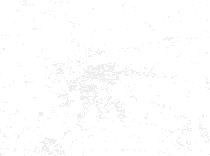
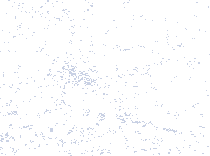
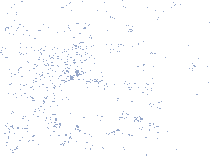
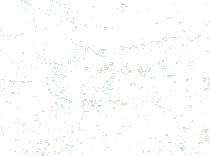
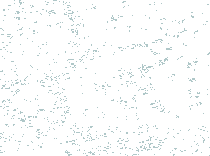
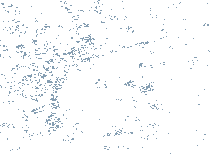
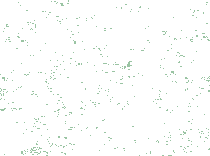
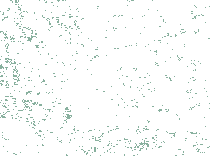
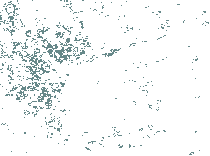
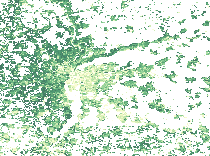
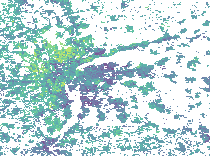

In [164]:
# ── Bivariate classification (3×3 quantile classes) ──────────────────────────
_N = 3

def _qclass(arr, k):
    flat = arr[np.isfinite(arr)]
    qs = np.quantile(flat, np.linspace(0, 1, k + 1))
    qs[-1] += 1e-9
    out = np.full(arr.shape, np.nan)
    for i in range(k):
        out[(arr >= qs[i]) & (arr < qs[i + 1])] = i
    return out

_cls_ver = _qclass(ds_clip["ver"].values.astype(float), _N)
_cls_snv = _qclass(ds_clip["ind_snv"].values.astype(float), _N)
_bv_combined = np.where(
    np.isfinite(_cls_ver) & np.isfinite(_cls_snv),
    _cls_ver * _N + _cls_snv, np.nan
)

_VEG_LABS = ["Low veg.", "Med. veg.", "High veg."]
_INC_LABS = ["Low income", "Med. income", "High income"]

# ── DualMap ───────────────────────────────────────────────────────────────────
# Left  : bivariate map — 9 individually toggleable colour classes
# Right : source layers (vegetation / income) for comparison
m9 = DualMap(location=_CENTER, zoom_start=12)
for tile_m in (m9.m1, m9.m2):
    folium.TileLayer("CartoDB positron", name="Basemap").add_to(tile_m)

# Left: one ImageOverlay per bivariate class
for ia in range(_N):
    for ib in range(_N):
        code  = ia * _N + ib
        color = _BIVAR_PALETTE_3x3[ia, ib]
        label = f"{_VEG_LABS[ia]} × {_INC_LABS[ib]}"
        mask  = _bv_combined == code
        if not mask.any():
            continue
        folium.raster_layers.ImageOverlay(
            image=_mask_to_png(mask, color, flip_y=_FLIP_Y),
            bounds=_BOUNDS, name=label, opacity=1.0,
            show=True, zindex=100 + code,
        ).add_to(m9.m1)

# Right: continuous vegetation + income layers
folium.raster_layers.ImageOverlay(
    image=_arr_to_png(ds_clip["ver"].values.astype(float), "YlGn", flip_y=_FLIP_Y),
    bounds=_BOUNDS, name="Vegetation cover (YlGn)",
    opacity=1.0, show=True,
).add_to(m9.m2)
folium.raster_layers.ImageOverlay(
    image=_arr_to_png(ds_clip["ind_snv"].values.astype(float), "viridis", flip_y=_FLIP_Y),
    bounds=_BOUNDS, name="Median income (viridis)",
    opacity=1.0, show=False,
).add_to(m9.m2)

folium.LayerControl(collapsed=False).add_to(m9.m1)
m9

---
### 4.1 Vegetation and climate justice — systematic comparison

The cell below loops over several climate-justice indicators and generates a bivariate map
pairing each with vegetation cover, so we can quickly test whether the same spatial
inequalities hold across dimensions.

> **❓ Question 10 · Vegetation and climate justice — multi-dimensional reading**
>
> Run the cell below. It generates three bivariate maps pairing vegetation cover with:
> - Median income (`ind_snv`)
> - Share of elderly 80+ (`ind_80p / ind`)
> - Impervious surface ratio (`ror`)
>
> For each map, answer:
> 1. **Income**: Do wealthier areas consistently have more vegetation?
>    Is the pattern stronger in the city centre or the periphery?
> 2. **Elderly share**: Are areas with many elderly residents also less vegetated?
>    Why does this matter during a heatwave?
> 3. **Impervious surface**: Where do high vegetation and high imperviousness coexist?
>    What urban form could explain this?
> 4. Taken together, do the three maps point to a consistent **climate injustice** pattern
>    in the Lyon area?  Which neighbourhood type is the most vulnerable, and why?


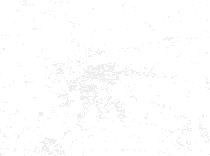
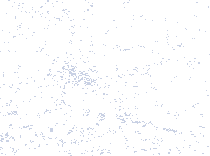
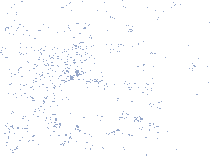
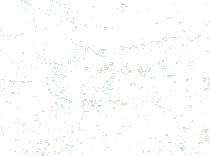
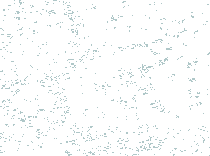
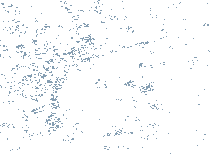
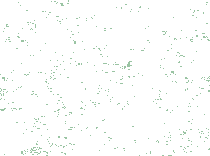
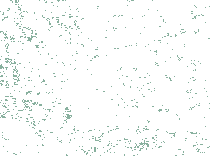
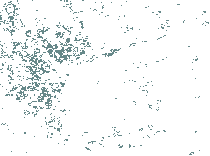


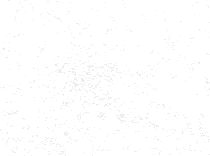
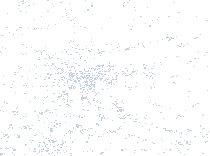
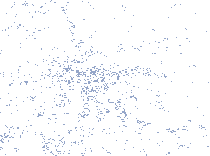
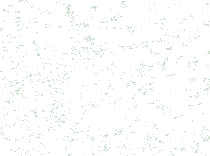
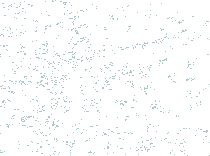
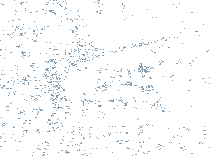
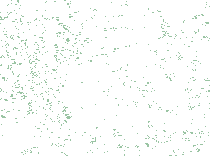
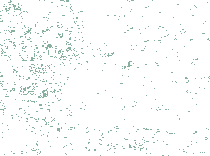
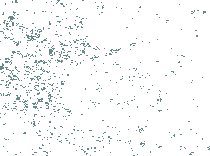


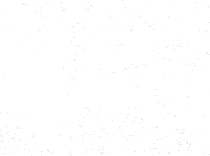
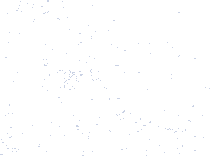
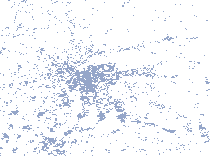
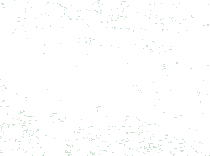
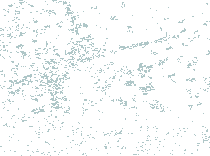
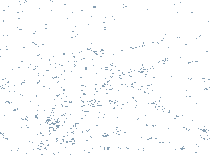
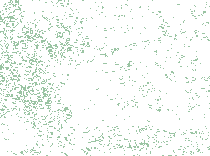
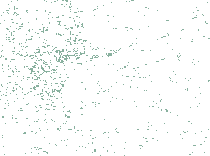

In [158]:
cj_configs = [
    dict(
        arr=ds_clip["ind_snv"].values.astype(float),
        label_b="income",
        title="Vegetation × Median income",
    ),
    dict(
        arr=(ds_clip["ind_80p"] / ds_clip["ind"].where(ds_clip["ind"] > 0)
             ).values.astype(float),
        label_b="elderly share",
        title="Vegetation × Share of elderly (80+)",
    ),
    dict(
        arr=ds_clip["ror"].values.astype(float),
        label_b="impervious surface",
        title="Vegetation × Impervious surface cover",
    ),
]

_labs_veg = ["Low veg.", "Med. veg.", "High veg."]

for cfg in cj_configs:
    cls_b   = _qclass(cfg["arr"], _N)
    valid   = np.isfinite(_cls_ver) & np.isfinite(cls_b)
    comb    = np.where(valid, _cls_ver * _N + cls_b, np.nan)
    _labs_b = [f"Low {cfg['label_b']}", f"Med. {cfg['label_b']}",
               f"High {cfg['label_b']}"]

    m = folium.Map(location=_CENTER, zoom_start=12, tiles=None)
    folium.TileLayer("CartoDB positron", name="Basemap").add_to(m)

    for ia in range(_N):
        for ib in range(_N):
            code  = ia * _N + ib
            color = _BIVAR_PALETTE_3x3[ia, ib]
            label = f"{_labs_veg[ia]} × {_labs_b[ib]}"
            mask  = comb == code
            if not mask.any():
                continue
            folium.raster_layers.ImageOverlay(
                image=_mask_to_png(mask, color, flip_y=_FLIP_Y),
                bounds=_BOUNDS, name=label, opacity=1.0,
                show=True, zindex=100 + code,
            ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    m.get_root().html.add_child(
        folium.Element(
            f'<h4 style="text-align:center;margin:6px 0;font-family:sans-serif">'
            f'{cfg["title"]}</h4>'
        )
    )
    display(m)

---
## Part 5 – Local Spatial Autocorrelation: Hot Spots and Cold Spots

Bivariate maps show *co-location* of two variables, but they do not tell us whether a
high-value cell is surrounded by other high-value cells — i.e., whether spatial **clusters**
exist and are statistically significant.

**Local Moran's I** (Anselin 1995) answers exactly that question for a single variable:

$$I_i = z_i \cdot \bar{z}_{\mathcal{N}(i)}$$

where $z_i$ is the standardised value at cell $i$ and $\bar{z}_{\mathcal{N}(i)}$ is the
mean standardised value in its queen neighbourhood (8 adjacent cells).

| Sign of $I_i$ | $z_i > 0$ | $z_i < 0$ |
|---------------|-----------|-----------|
| $I_i > 0$ (neighbours agree) | **HH** – high–high hotspot | **LL** – low–low coldspot |
| $I_i < 0$ (neighbours differ) | **HL** – spatial outlier | **LH** – spatial outlier |

Significance is assessed via a conditional permutation test (999 random shuffles of the
values at all *other* cells, keeping $z_i$ fixed).

We apply this to **vegetation cover** and **median income** separately, then overlay both
LISA maps to identify zones that are simultaneously vegetation-poor and income-poor (the
most heat-vulnerable areas).

In [159]:
from scipy.ndimage import convolve as ndimage_convolve

# ── Local Moran's I on a 2D raster (queen contiguity) ─────────────────────────
def local_morans_i(arr, n_perms=999, alpha=0.05, seed=42):
    """
    Compute Local Moran's I for each cell of a 2D raster.

    Parameters
    ----------
    arr      : 2D float array (NaN = missing)
    n_perms  : number of permutations for the pseudo p-value
    alpha    : significance level

    Returns
    -------
    li       : Local Moran's I values (same shape as arr)
    cluster  : integer map   1=HH  2=LL  3=HL  4=LH  0=ns  NaN=missing
    p_val    : pseudo p-values
    """
    valid = np.isfinite(arr)
    flat  = arr[valid]
    mu, sigma = flat.mean(), flat.std()
    z     = np.where(valid, (arr - mu) / sigma, np.nan)
    z0    = np.where(valid, z, 0.0)          # NaN → 0 for convolution

    # Queen kernel (8 neighbours)
    W = np.array([[1, 1, 1],
                  [1, 0, 1],
                  [1, 1, 1]], dtype=float)

    n_neigh   = ndimage_convolve(valid.astype(float), W, mode="constant", cval=0)
    lag_sum   = ndimage_convolve(z0, W, mode="constant", cval=0)
    spatial_lag = np.where(n_neigh > 0, lag_sum / n_neigh, np.nan)
    li = np.where(valid, z * spatial_lag, np.nan)

    # ── Conditional permutation test ─────────────────────────────────────────
    # For each permutation, shuffle z values globally and recompute spatial lag.
    # p-value = fraction of |Li_perm| >= |Li|  (two-sided)
    rng     = np.random.default_rng(seed)
    flat_z  = z[valid]
    p_count = np.zeros(arr.shape, dtype=float)

    for _ in range(n_perms):
        z_perm       = np.full(arr.shape, np.nan)
        z_perm[valid] = rng.permutation(flat_z)
        z0_perm       = np.where(valid, z_perm, 0.0)
        lag_perm      = np.where(
            n_neigh > 0,
            ndimage_convolve(z0_perm, W, mode="constant", cval=0) / n_neigh,
            np.nan,
        )
        li_perm = np.where(valid, z * lag_perm, np.nan)
        # accumulate where |li_perm| >= |li|
        with np.errstate(invalid="ignore"):
            p_count += np.where(
                valid & np.isfinite(li_perm),
                (np.abs(li_perm) >= np.abs(li)).astype(float),
                0.0,
            )

    p_val = np.where(valid, p_count / n_perms, np.nan)

    # ── Classify ─────────────────────────────────────────────────────────────
    cluster = np.full(arr.shape, np.nan)
    sig = valid & (p_val <= alpha)

    cluster[sig & (z > 0) & (spatial_lag > 0)] = 1   # HH – hotspot
    cluster[sig & (z < 0) & (spatial_lag < 0)] = 2   # LL – coldspot
    cluster[sig & (z > 0) & (spatial_lag < 0)] = 3   # HL – outlier (high, low nbrs)
    cluster[sig & (z < 0) & (spatial_lag > 0)] = 4   # LH – outlier (low, high nbrs)
    cluster[valid & ~sig]                        = 0  # not significant

    return li, cluster, p_val


# ── Helper: plot a LISA cluster map ──────────────────────────────────────────
_LISA_COLORS = {
    1: "#d7191c",   # HH – red
    2: "#2c7bb6",   # LL – blue
    3: "#fdae61",   # HL – orange
    4: "#abd9e9",   # LH – light blue
    0: "#cccccc",   # ns – grey
}
_LISA_LABELS = {
    1: "HH – hotspot",
    2: "LL – coldspot",
    3: "HL – spatial outlier",
    4: "LH – spatial outlier",
    0: "Not significant",
}

def plot_lisa_map(da, cluster, *, title="LISA cluster map", figsize=(10, 7),
                  same_crs="EPSG:3857"):
    """
    Plot a LISA cluster map from a DataArray with CRS and the cluster integer array.
    """
    da_r = _prepare_da_for_map(da, target_crs=same_crs)
    x = da_r["x"].values
    y = da_r["y"].values
    extent = [float(np.nanmin(x)), float(np.nanmax(x)),
              float(np.nanmin(y)), float(np.nanmax(y))]

    # Build RGB image
    h, w = cluster.shape
    rgb = np.ones((h, w, 4))   # RGBA, default white (missing)
    from matplotlib.colors import to_rgba
    for code, color in _LISA_COLORS.items():
        mask = cluster == code
        rgba = to_rgba(color)
        rgb[mask] = rgba

    rivers, lakes = _load_rivers_and_lakes(target_crs=same_crs)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(rgb, extent=extent, origin="lower", zorder=3, interpolation="nearest")

    if not lakes.empty:
        lakes.clip(box(*extent)).plot(ax=ax, color="#9ecae1", edgecolor="#6baed6",
                                      linewidth=0.4, alpha=0.9, zorder=2)
    if not rivers.empty:
        rivers.clip(box(*extent)).plot(ax=ax, color="#3182bd", linewidth=0.7,
                                       alpha=0.9, zorder=4)

    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_axis_off()
    ax.set_title(title, fontweight="bold")

    handles = [mpatches.Patch(facecolor=c, label=_LISA_LABELS[k])
               for k, c in _LISA_COLORS.items()]
    ax.legend(handles=handles, loc="lower left", fontsize=9, frameon=True)

    plt.tight_layout()
    return fig, ax

### 5.1 LISA for vegetation cover and median income

We compute Local Moran's I on:
1. **Vegetation cover** (`ver`) – HH clusters = green oases; LL clusters = vegetation deserts
2. **Median income** (`ind_snv`) – HH clusters = wealthy zones; LL clusters = deprived zones

*Note: 999 permutations per variable — this may take ~1–2 minutes.*

In [160]:
# ── Compute LISA for vegetation and income ────────────────────────────────────
arr_ver = ds_clip["ver"].values.astype(float)
arr_snv = ds_clip["ind_snv"].values.astype(float)

print("Computing LISA for vegetation cover...")
li_ver, cluster_ver, p_ver = local_morans_i(arr_ver, n_perms=999)
print("Computing LISA for median income...")
li_snv, cluster_snv, p_snv = local_morans_i(arr_snv, n_perms=999)
print("Done.")

# ── Summary statistics ────────────────────────────────────────────────────────
for name, cluster in [("Vegetation (ver)", cluster_ver), ("Income (ind_snv)", cluster_snv)]:
    total = np.sum(np.isfinite(cluster))
    print(f"\n{name}")
    for code, label in _LISA_LABELS.items():
        n = np.sum(cluster == code)
        print(f"  {label:30s}: {n:6,.0f}  ({100*n/total:.1f} %)")

Computing LISA for vegetation cover...
Computing LISA for median income...
Done.

Vegetation (ver)
  HH – hotspot                  :  1,408  (10.6 %)
  LL – coldspot                 :  1,844  (13.9 %)
  HL – spatial outlier          :    179  (1.3 %)
  LH – spatial outlier          :    127  (1.0 %)
  Not significant               :  9,737  (73.2 %)

Income (ind_snv)
  HH – hotspot                  :  1,989  (15.0 %)
  LL – coldspot                 :  1,914  (14.4 %)
  HL – spatial outlier          :     88  (0.7 %)
  LH – spatial outlier          :    144  (1.1 %)
  Not significant               :  9,160  (68.9 %)



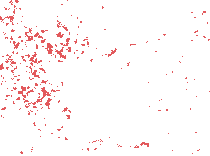
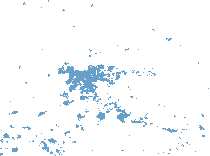
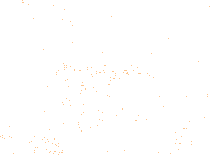
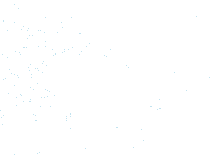
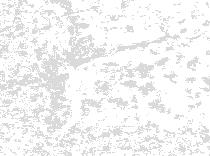
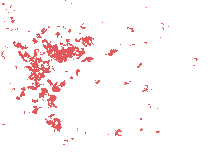
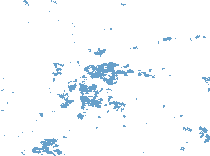
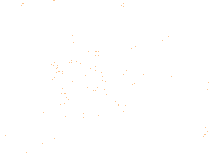
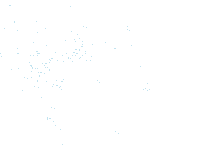
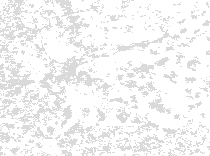

In [161]:
# ── Folium DualMap: left = vegetation LISA, right = income LISA ───────────────
m_lisa = DualMap(location=_CENTER, zoom_start=12)
for tile_m in (m_lisa.m1, m_lisa.m2):
    folium.TileLayer("CartoDB positron", name="Basemap").add_to(tile_m)

for code, color in _LISA_COLORS.items():
    label = _LISA_LABELS[code]

    # Left panel: vegetation LISA
    mask_ver = cluster_ver == code
    if mask_ver.any():
        folium.raster_layers.ImageOverlay(
            image=_mask_to_png(mask_ver, color, flip_y=_FLIP_Y),
            bounds=_BOUNDS, name=label, opacity=1.0,
            show=(code != 0), zindex=100 + code,
        ).add_to(m_lisa.m1)

    # Right panel: income LISA
    mask_snv = cluster_snv == code
    if mask_snv.any():
        folium.raster_layers.ImageOverlay(
            image=_mask_to_png(mask_snv, color, flip_y=_FLIP_Y),
            bounds=_BOUNDS, name=label, opacity=1.0,
            show=(code != 0), zindex=100 + code,
        ).add_to(m_lisa.m2)

folium.LayerControl(collapsed=False).add_to(m_lisa.m1)
folium.LayerControl(collapsed=False).add_to(m_lisa.m2)
m_lisa

### 5.2 Local Lee's L — bivariate spatial autocorrelation

Instead of overlaying two separate LISA maps, we use the **Local Lee's L statistic**
(Lee 2001), which directly measures the *bivariate* spatial co-variation of two variables at
each location:

$$L_i = \frac{1}{2}\!\left(z_{x,i}\,\bar{z}_{y,i} + z_{y,i}\,\bar{z}_{x,i}\right)$$

where $\bar{z}_{y,i}$ is the row-standardised queen-neighbourhood lag of $z_y$.

$L_i > 0$ means the two variables **co-cluster** at location $i$ — both are high together
(HH) or both are low together (LL).  
$L_i < 0$ means a **spatial mismatch** — one variable is high while the other is low in
the neighbourhood (HL or LH).

Applied here with **x = vegetation** and **y = income**:

| Quadrant | Interpretation |
|----------|----------------|
| **LL** (dark red) | Low veg AND low-income neighbourhood → **double-burden hotspot** |
| **HH** (dark blue) | High veg AND high-income neighbourhood → privileged green zone |
| **HL** (orange) | High veg, low-income neighbourhood → green but poor |
| **LH** (light blue) | Low veg, high-income neighbourhood → affluent but built-up |

Significance is assessed by permuting $z_y$ (999 shuffles), keeping $z_x$ fixed.

In [162]:
def local_lee_l(arr_x, arr_y, n_perms=999, alpha=0.05, seed=42):
    """
    Local Lee's L bivariate spatial autocorrelation (Lee 2001).

    L_i = 0.5 * (z_x,i * lag(z_y)_i  +  z_y,i * lag(z_x)_i)

    Quadrant classification (significant cells only):
        1 = HH  z_x > 0, lag(z_y) > 0  → both co-cluster high
        2 = LL  z_x < 0, lag(z_y) < 0  → both co-cluster low  (vulnerability hotspot)
        3 = HL  z_x > 0, lag(z_y) < 0  → spatial mismatch
        4 = LH  z_x < 0, lag(z_y) > 0  → spatial mismatch
        0 = not significant
    """
    valid = np.isfinite(arr_x) & np.isfinite(arr_y)

    def _standardise(arr):
        flat = arr[valid]
        return np.where(valid, (arr - flat.mean()) / flat.std(), np.nan)

    zx = _standardise(arr_x)
    zy = _standardise(arr_y)

    W = np.array([[1, 1, 1],
                  [1, 0, 1],
                  [1, 1, 1]], dtype=float)
    valid_f = valid.astype(float)
    n_neigh = ndimage_convolve(valid_f, W, mode="constant", cval=0)

    def _lag(z):
        z0 = np.where(valid, z, 0.0)
        lag_sum = ndimage_convolve(z0, W, mode="constant", cval=0)
        return np.where(n_neigh > 0, lag_sum / n_neigh, np.nan)

    lag_zx = _lag(zx)
    lag_zy = _lag(zy)

    L = np.where(valid, 0.5 * (zx * lag_zy + zy * lag_zx), np.nan)

    # ── Permutation test: fix z_x, shuffle z_y ───────────────────────────────
    rng    = np.random.default_rng(seed)
    flat_zy = zy[valid]
    p_count = np.zeros(arr_x.shape, dtype=float)

    for _ in range(n_perms):
        zy_perm        = np.full(arr_x.shape, np.nan)
        zy_perm[valid] = rng.permutation(flat_zy)
        lag_zy_perm    = _lag(zy_perm)
        zy_perm0       = np.where(valid, zy_perm, 0.0)
        L_perm = np.where(valid,
                          0.5 * (zx * lag_zy_perm + zy_perm * lag_zx), np.nan)
        with np.errstate(invalid="ignore"):
            p_count += np.where(
                valid & np.isfinite(L_perm),
                (np.abs(L_perm) >= np.abs(L)).astype(float),
                0.0,
            )

    p_val = np.where(valid, p_count / n_perms, np.nan)

    # ── Classify by sign of z_x and lag(z_y) ─────────────────────────────────
    cluster = np.full(arr_x.shape, np.nan)
    sig = valid & (p_val <= alpha)

    cluster[sig & (zx > 0) & (lag_zy > 0)] = 1   # HH
    cluster[sig & (zx < 0) & (lag_zy < 0)] = 2   # LL  ← double burden
    cluster[sig & (zx > 0) & (lag_zy < 0)] = 3   # HL
    cluster[sig & (zx < 0) & (lag_zy > 0)] = 4   # LH
    cluster[valid & ~sig]                   = 0   # not significant

    return L, cluster, p_val, lag_zy


# ── Compute Local Lee's L for vegetation × income ────────────────────────────
print("Computing Local Lee's L (vegetation × income)  — 999 permutations …")
L_vi, cluster_lee, p_lee, lag_zy_vi = local_lee_l(
    arr_ver, arr_snv, n_perms=999
)
print("Done.")

# ── Summary ───────────────────────────────────────────────────────────────────
labels_lee = {1: "HH – both high",
              2: "LL – both low (double burden)",
              3: "HL – high veg, low-income neighbours",
              4: "LH – low veg, high-income neighbours",
              0: "Not significant"}
total_lee = int(np.sum(np.isfinite(cluster_lee)))
print(f"\nLocal Lee's L  (vegetation × income)  —  n = {total_lee:,} cells")
for code, label in labels_lee.items():
    n = int(np.sum(cluster_lee == code))
    print(f"  {label:45s}: {n:6,}  ({100*n/total_lee:.1f} %)")

Computing Local Lee's L (vegetation × income)  — 999 permutations …
Done.

Local Lee's L  (vegetation × income)  —  n = 13,295 cells
  HH – both high                               :  1,340  (10.1 %)
  LL – both low (double burden)                :  1,122  (8.4 %)
  HL – high veg, low-income neighbours         :    174  (1.3 %)
  LH – low veg, high-income neighbours         :    187  (1.4 %)
  Not significant                              : 10,472  (78.8 %)



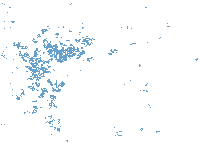
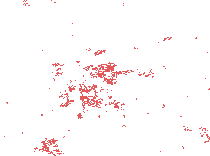
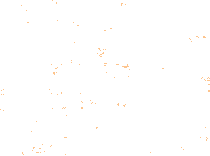
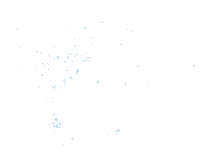
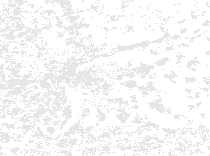

In [163]:
# ── Folium map for Local Lee's L — one toggleable layer per quadrant ─────────
m_lee = folium.Map(location=_CENTER, zoom_start=12, tiles=None)
folium.TileLayer("CartoDB positron", name="Basemap").add_to(m_lee)

for code, color in _LEE_COLORS.items():
    mask = cluster_lee == code
    if not mask.any():
        continue
    folium.raster_layers.ImageOverlay(
        image=_mask_to_png(mask, color, flip_y=_FLIP_Y),
        bounds=_BOUNDS,
        name=_LEE_LABELS[code],
        opacity=1.0,
        show=(code != 0),     # hide "not significant" by default
        zindex=100 + code,
    ).add_to(m_lee)

folium.LayerControl(collapsed=False).add_to(m_lee)
m_lee

> **❓ Question 12 · Local spatial autocorrelation — LISA and Local Lee's L**
>
> **Part A — Reading the univariate LISA maps (section 5.1)**
>
> 1. Where are the **HH vegetation clusters** (green hotspots)?
>    Are they inside the city or on the periphery?
> 2. Where are the **LL vegetation clusters** (vegetation deserts)?
>    Do they coincide with densely built LCZ classes (1–3)?
> 3. Do the **LL income clusters** and the **LL vegetation clusters** overlap spatially?
>
> **Part B — Local Lee's L map (section 5.2)**
>
> 4. What is the geographic distribution of the **LL double-burden hotspots**
>    (low vegetation co-clustering with low income)?
>    Which parts of the Lyon area are most affected?
> 5. The **HL cells** (high vegetation, low-income neighbourhood) represent a different
>    spatial configuration. What urban or peri-urban form could produce this pattern?
> 6. Compare the Local Lee's L map with the bivariate map from Question 9.
>    - Do both methods identify the same vulnerable zones?
>    - What does Local Lee's L add that the bivariate map alone cannot show?
>    *(Hint: think about statistical significance and spatial contiguity.)*
>
> **Part C — Methodology**
>
> 7. **Lee vs. double-LISA overlay**: why is computing a single $L_i$ statistic on the
>    pair (vegetation, income) more rigorous than overlaying two separate LISA maps?
> 8. The permutation test fixes $z_x$ (vegetation) and shuffles $z_y$ (income).
>    What null hypothesis does this test?
>    Would the result change if we also shuffled $z_x$?
> 9. What are the limits of this raster-based approach compared to working with
>    administrative polygons (IRIS, quartier)?
>    When would one scale be preferred over the other?

---
## Conclusion

In this notebook we have shown that Lyon, like most French cities, is experiencing:

1. **Accelerating warming** – roughly +3 °C over 55 years, with more frequent and longer heatwaves.
2. **Unequal exposure** – lower-income urban areas have less vegetation, more impervious surfaces, and greater distances to healthcare.
3. **Climate justice concerns** – the populations least responsible for climate change bear a disproportionate share of its health consequences.

### Further reading


- Lemonsu et al. (2015). *Vulnerability to heat waves: Future heat exposure and human comfort for the agglomeration of Marseille.* Urban Climate.
- Stewart & Oke (2012). *Local Climate Zones for Urban Ecosystem Studies.* BAMS.
- Tuholske et al. (2021). *Global urban population exposure to extreme heat.* PNAS.
